# Pothole Detection | Hybrid Models
**Models:** YOLOv8m+CBAM, YOLOv8m+CoordAttn, YOLO+FasterRCNN Ensemble 

In [1]:
# Frees GPU memory by deleting any model objects left in the namespace from a previous run and emptying the CUDA cache.
import torch, gc

# Delete any existing models in memory
for var in [
    "cbam_yolo",
    "ca_yolo",
    "yolo_ens",
    "frcnn_ens",
    "cbam_injector",
    "ca_injector",
    "test_model",
    "test_model_cbam",
    "test_model_ca",
]:
    if var in dir():
        del var

# Clear GPU cache
torch.cuda.empty_cache()
gc.collect()

# Check memory after clearing
print("GPU Memory after clearing:")
print(f"  Allocated : {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
print(f"  Reserved  : {torch.cuda.memory_reserved() / 1024**2:.1f} MB")
print(
    f"  Free      : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1024**2:.1f} MB"
)
print(
    f"  Total     : {torch.cuda.get_device_properties(0).total_memory / 1024**2:.1f} MB"
)

GPU Memory after clearing:
  Allocated : 0.0 MB
  Reserved  : 0.0 MB
  Free      : 24251.6 MB
  Total     : 24251.6 MB


In [2]:
2  # Prints the GPU name to confirm which device the notebook is running on.
import torch

print(f"   GPU: {torch.cuda.get_device_name(0)}")

   GPU: NVIDIA GeForce RTX 3090


In [4]:
# Detects whether the notebook is running on Kaggle, Colab, or local Jupyter and sets ROOT, SAVE_DIR, HYBRID_DIR and OUTPUT_DIR accordingly.
import os, sys

ON_KAGGLE = os.path.exists("/kaggle/input")
ON_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
ON_JUPYTER = not ON_KAGGLE and not ON_COLAB

if ON_KAGGLE:
    print("Running on KAGGLE")
    ROOT = "/kaggle/working"
    SAVE_DIR = "/kaggle/working/saved_models"
elif ON_COLAB:
    print("Running on GOOGLE COLAB")
    ROOT = "/content"
    SAVE_DIR = "/content/saved_models"
else:
    print("Running on LOCAL JUPYTER")
    ROOT = "."
    SAVE_DIR = "./saved_models"

OUTPUT_DIR = os.path.join(ROOT, "hybrid_results")
DATA_DIR = os.path.join(ROOT, "data")
HYBRID_DIR = os.path.join(ROOT, "hybrid_models")

for d in [OUTPUT_DIR, DATA_DIR, HYBRID_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"   Output       -> {OUTPUT_DIR}")
print(f"   Base Weights -> {SAVE_DIR}")
print(f"   Hybrid Saves -> {HYBRID_DIR}")

Running on LOCAL JUPYTER
   Output       -> ./hybrid_results
   Base Weights -> ./saved_models
   Hybrid Saves -> ./hybrid_models


In [5]:
# Loads all shared imports and defines the fixed evaluation config, DEVICE, CONF_THRESH, IOU_THRESH, IMG_SIZE, and the chart palette.
import time, json, glob, warnings, xml.etree.ElementTree as ET
import cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CONF_THRESH = 0.25
IOU_THRESH = 0.45
IMG_SIZE = 640
MAX_IMAGES = 150
NUM_WORKERS = (
    2  # cluster-safe Ultralytics/torchvision defaults (8) can exceed cluster ulimits
)


EPOCHS_FROZEN = 10  # phase 1: backbone frozen, attention learns fast
LR_FROZEN = 1e-3
EPOCHS_FULL = 40  # phase 2: everything trains together, gently
LR_FULL = 2e-4
WEIGHT_DECAY = 5e-4

# Confidence grid for the F1 operating-point sweep
CONF_SWEEP = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
]

# Paths to our fine-tuned base weights
YOLOV8M_WEIGHTS = f"{SAVE_DIR}/YOLOv8m_finetuned.pt"
FASTERRCNN_WEIGHTS = f"{SAVE_DIR}/faster_rcnn_finetuned.pth"

PALETTE = {
    "YOLOv8m+CBAM": "#f59e0b",
    "YOLOv8m+CoordAttn": "#10b981",
    "YOLO+FRCNN Ensemble": "#8b5cf6",
    "YOLOv8m (base)": "#00d4ff",
    "Faster R-CNN (base)": "#f97316",
}

print(f" Config loaded  |  Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
print(
    f"   Two-phase: {EPOCHS_FROZEN}ep @ lr={LR_FROZEN} (freeze=10) "
    f"-> {EPOCHS_FULL}ep @ lr={LR_FULL} (freeze=0)"
)

# Quick weight file check
for name, path in [("YOLOv8m", YOLOV8M_WEIGHTS), ("Faster R-CNN", FASTERRCNN_WEIGHTS)]:
    exists = os.path.exists(path)
    print(f"   {name} weights: {'FOUND' if exists else 'NOT FOUND'} at {path}")


 Config loaded  |  Device: cuda
   GPU: NVIDIA GeForce RTX 3090
   Two-phase: 10ep @ lr=0.001 (freeze=10) -> 40ep @ lr=0.0002 (freeze=0)
   YOLOv8m weights: FOUND at ./saved_models/YOLOv8m_finetuned.pt
   Faster R-CNN weights: FOUND at ./saved_models/faster_rcnn_finetuned.pth


In [6]:
# Downloads the three Kaggle datasets, loads them through the unified annotation loader, deduplicates, and defines the canonical train/val split shared with the other notebooks.
import kagglehub
from pathlib import Path

print(" Downloading datasets via kagglehub ...")
path_1 = kagglehub.dataset_download("chitholian/annotated-potholes-dataset")
path_2 = kagglehub.dataset_download("andrewmvd/pothole-detection")
path_3 = kagglehub.dataset_download("ashishkumarak/training-setzip")

DATASET_ROOTS = {"chitholian": path_1, "andrewmvd": path_2, "ashishkumar": path_3}
print("Datasets ready")


import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from PIL import Image


def load_annotated_potholes(root):
    root = Path(root)
    records = []
    for img_path in list(root.rglob("*.jpg")) + list(root.rglob("*.png")):
        xml_path = img_path.with_suffix(".xml")
        if not xml_path.exists():
            xml_path = img_path.parent.parent / "annotations" / (img_path.stem + ".xml")
        gt_boxes = []
        if xml_path.exists():
            try:
                tree = ET.parse(xml_path)
                for obj in tree.findall("object"):
                    bb = obj.find("bndbox")
                    gt_boxes.append(
                        {
                            "label": (obj.find("name").text or "pothole").lower(),
                            "xmin": float(bb.find("xmin").text),
                            "ymin": float(bb.find("ymin").text),
                            "xmax": float(bb.find("xmax").text),
                            "ymax": float(bb.find("ymax").text),
                        }
                    )
            except Exception:
                pass
        records.append({"image_path": img_path, "gt_boxes": gt_boxes})
    return records


def load_ashishkumar_csv(root):
    root = Path(root)
    csv_path = root / "train" / "labels.csv"
    img_dir = root / "train" / "images"
    df = pd.read_csv(csv_path)
    grouped = df.groupby("ImageID")

    records = []
    for img_path in sorted(img_dir.glob("*.jpg")):
        gt_boxes = []
        if img_path.name in grouped.groups:
            for _, row in grouped.get_group(img_path.name).iterrows():
                gt_boxes.append(
                    {
                        "label": "pothole",
                        "xmin": float(row["XMin"]),
                        "ymin": float(row["YMin"]),
                        "xmax": float(row["XMax"]),
                        "ymax": float(row["YMax"]),
                    }
                )
        records.append({"image_path": img_path, "gt_boxes": gt_boxes})
    return records


all_records = []
for name, root in DATASET_ROOTS.items():
    if name == "ashishkumar":
        recs = load_ashishkumar_csv(root)
    else:
        recs = load_annotated_potholes(root)
    print(
        f"  {name}: {len(recs)} images ({sum(len(r['gt_boxes']) for r in recs)} gt boxes)"
    )
    all_records.extend(recs)

print(f"\nTotal images before dedup: {len(all_records)}")

# Normalized-pixel nearest-neighbor dedup (robust to re-encoding differences)
NORM_SIZE = (64, 64)
DEDUP_THRESHOLD = 1.0  # mean abs pixel diff (0-255 scale), true duplicates
# measured at 0.10-0.50, unrelated images much higher


def normalized_pixels(path):
    with Image.open(path) as img:
        return np.asarray(
            img.convert("L").resize(NORM_SIZE, Image.LANCZOS), dtype=np.float32
        ).ravel()


annotated_only = [r for r in all_records if r["gt_boxes"]]
print("Computing normalized pixel arrays for dedup ...")
all_arrs = np.stack([normalized_pixels(r["image_path"]) for r in annotated_only])

keep_mask = np.ones(len(annotated_only), dtype=bool)
seen_arrs = []
for i in range(len(annotated_only)):
    if not keep_mask[i]:
        continue
    if seen_arrs:
        diffs = np.abs(np.stack(seen_arrs) - all_arrs[i]).mean(axis=1)
        if diffs.min() < DEDUP_THRESHOLD:
            keep_mask[i] = False
            continue
    seen_arrs.append(all_arrs[i])

records = [r for r, keep in zip(annotated_only, keep_mask) if keep]

n_before = len(all_records)
n_after = len(records)
print(f"Total images after dedup: {n_after}")
print(f"   Duplicates removed: {n_before - n_after}")


import random as _random

_random.seed(42)
_shuffled = records.copy()
_random.shuffle(_shuffled)
_split_idx = int(len(_shuffled) * 0.8)
train_recs = _shuffled[:_split_idx]
val_recs = _shuffled[_split_idx:]
print(
    f"\nCanonical split: train={len(train_recs)}  val={len(val_recs)}  "
    f"(seed=42, shared by all training and evaluation cells below)"
)


Datasets ready
  chitholian: 665 images (1740 gt boxes)
  andrewmvd: 665 images (1740 gt boxes)
  ashishkumar: 674 images (1371 gt boxes)

Total images before dedup: 2004
Computing normalized pixel arrays for dedup ...
Total images after dedup: 926
   Duplicates removed: 1078

Canonical split: train=740  val=186  (seed=42, shared by all training and evaluation cells below)



## Fine-tune YOLOv8m baseline

In [7]:
# Fine-tunes the YOLOv8m baseline that serves as the ensemble's YOLO member, converting the canonical split to YOLO format first and skipping if the weights already exist.
import shutil, yaml, gc
from ultralytics import YOLO

YOLO_DIR = os.path.join(ROOT, "yolo_dataset")
DATA_YAML = f"{YOLO_DIR}/data.yaml"


def ensure_yolo_dataset():
    """Build the YOLO-format dataset from `records` if not already present.
    Idempotent safe to call multiple times or after a job restart."""
    if os.path.exists(DATA_YAML):
        print(f"data.yaml found -> {DATA_YAML}")
        return
    print("WARNING: yolo_dataset not found -- creating it now ...")
    for split in ["images/train", "images/val", "labels/train", "labels/val"]:
        os.makedirs(f"{YOLO_DIR}/{split}", exist_ok=True)

    def convert_to_yolo(rec_list, split):
        for rec in rec_list:
            img = cv2.imread(str(rec["image_path"]))
            if img is None:
                continue
            h, w = img.shape[:2]
            dst = f"{YOLO_DIR}/images/{split}/{rec['image_path'].name}"
            if not os.path.exists(dst):
                shutil.copy(str(rec["image_path"]), dst)
            with open(
                f"{YOLO_DIR}/labels/{split}/{rec['image_path'].stem}.txt", "w"
            ) as f:
                for g in rec["gt_boxes"]:
                    cx = ((g["xmin"] + g["xmax"]) / 2) / w
                    cy = ((g["ymin"] + g["ymax"]) / 2) / h
                    bw = (g["xmax"] - g["xmin"]) / w
                    bh = (g["ymax"] - g["ymin"]) / h
                    f.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

    convert_to_yolo(train_recs, "train")
    convert_to_yolo(val_recs, "val")
    with open(DATA_YAML, "w") as f:
        yaml.dump(
            {
                "path": YOLO_DIR,
                "train": "images/train",
                "val": "images/val",
                "nc": 1,
                "names": ["pothole"],
            },
            f,
        )
    print(f" data.yaml created at {DATA_YAML}")


if os.path.exists(YOLOV8M_WEIGHTS):
    print(f" YOLOv8m weights already exist at {YOLOV8M_WEIGHTS}  (skipping training)")
else:
    ensure_yolo_dataset()

    print("\n Fine-tuning YOLOv8m baseline ...")
    yolo_base = YOLO("yolov8m.pt")
    yolo_base.to(DEVICE)

    try:
        yolo_base.train(
            data=DATA_YAML,
            epochs=50,
            imgsz=IMG_SIZE,
            batch=16,
            lr0=1e-3,
            device=DEVICE,
            name="YOLOv8m_baseline_hybrid",
            exist_ok=True,  #  allows safe resume/re-run without name clashes
            workers=NUM_WORKERS,  #  cluster-safe worker count
            verbose=False,
            plots=False,
            save=True,
        )
    except Exception as e:
        print(f" Training failed: {e}")
        raise
    finally:
        # Always free GPU memory, even if training raised
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    best = "runs/detect/YOLOv8m_baseline_hybrid/weights/best.pt"
    last = "runs/detect/YOLOv8m_baseline_hybrid/weights/last.pt"
    src_weights = best if os.path.exists(best) else last
    os.makedirs(SAVE_DIR, exist_ok=True)
    shutil.copy(src_weights, YOLOV8M_WEIGHTS)
    print(f" YOLOv8m baseline saved -> {YOLOV8M_WEIGHTS}")

    del yolo_base
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


 YOLOv8m weights already exist at ./saved_models/YOLOv8m_finetuned.pt  (skipping training)


---
## Fine-tune Faster R-CNN baseline (self-contained, cluster-safe)

torchvision has no built-in `.train()` like Ultralytics, so this is a
manual training loop. Cluster-safety measures: `num_workers=2` (not the
often-higher framework default), per-epoch checkpointing to disk so a
killed/resumed cluster job doesn't lose progress, a `try/except/finally`
around the training loop so GPU memory is always freed even on failure,
and automatic skip if a final checkpoint already exists.

In [8]:
# Fine-tunes the Faster R-CNN baseline that serves as the ensemble's second member, with a manual training loop, per-epoch checkpointing, and automatic skip if a final checkpoint exists.
import gc, json as _json
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

FRCNN_EPOCHS = 20
FRCNN_LR = 5e-4
FRCNN_BATCH = 4  # Faster R-CNN is far more memory-hungry per-image than YOLO
FRCNN_CKPT_DIR = os.path.join(HYBRID_DIR, "frcnn_checkpoints")
os.makedirs(FRCNN_CKPT_DIR, exist_ok=True)


def _valid_box(g, min_size=1.0):
    """FIX: torchvision's Faster R-CNN hard-crashes (AssertionError, not a
    catchable-per-batch warning) on any box with zero or negative width/
    height. A single bad annotation anywhere in the dataset kills the
    entire training run. Filter degenerate boxes defensively min_size=1.0
    also drops sub-pixel boxes that are technically positive-area but
    numerically risky."""
    w = g["xmax"] - g["xmin"]
    h = g["ymax"] - g["ymin"]
    return w >= min_size and h >= min_size


class PotholeDatasetFRCNN(Dataset):
    """Wraps `records` (image_path + gt_boxes dicts) for torchvision detection."""

    def __init__(self, recs):
        # Filter degenerate boxes per-record at construction time, and
        # drop any record left with zero valid boxes afterward (rather than
        # only checking `if r['gt_boxes']`, which doesn't catch a record
        # whose boxes are all degenerate).
        self.recs = []
        n_dropped_boxes = 0
        n_dropped_images = 0
        for r in recs:
            valid_boxes = [g for g in r["gt_boxes"] if _valid_box(g)]
            n_dropped_boxes += len(r["gt_boxes"]) - len(valid_boxes)
            if valid_boxes:
                self.recs.append({**r, "gt_boxes": valid_boxes})
            elif r["gt_boxes"]:
                n_dropped_images += 1
        if n_dropped_boxes or n_dropped_images:
            print(
                f" Dropped {n_dropped_boxes} degenerate box(es) "
                f"({n_dropped_images} image(s) left with no valid boxes, excluded)"
            )

    def __len__(self):
        return len(self.recs)

    def __getitem__(self, idx):
        rec = self.recs[idx]
        img = cv2.imread(str(rec["image_path"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        boxes, labels = [], []
        for g in rec["gt_boxes"]:
            boxes.append([g["xmin"], g["ymin"], g["xmax"], g["ymax"]])
            labels.append(1)  # single class: pothole

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
        }
        return img_t, target


def frcnn_collate_fn(batch):
    return tuple(zip(*batch))


if os.path.exists(FASTERRCNN_WEIGHTS):
    print(
        f"Faster R-CNN weights already exist at {FASTERRCNN_WEIGHTS}  (skipping training)"
    )
else:
    print("\nFine-tuning Faster R-CNN baseline ...")

    train_ds = PotholeDatasetFRCNN(train_recs)
    train_loader = DataLoader(
        train_ds,
        batch_size=FRCNN_BATCH,
        shuffle=True,
        num_workers=NUM_WORKERS,  # cluster-safe, not torchvision's higher default
        collate_fn=frcnn_collate_fn,
    )

    frcnn_model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")
    in_feat = frcnn_model.roi_heads.box_predictor.cls_score.in_features
    frcnn_model.roi_heads.box_predictor = FastRCNNPredictor(
        in_feat, num_classes=2
    )  # background + pothole
    frcnn_model.to(DEVICE)

    params = [p for p in frcnn_model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=FRCNN_LR, momentum=0.9, weight_decay=5e-4)

    start_epoch = 0
    ckpt_files = sorted(glob.glob(os.path.join(FRCNN_CKPT_DIR, "epoch_*.pt")))
    if ckpt_files:
        latest = ckpt_files[-1]
        print(f"   Resuming from checkpoint: {latest}")
        ckpt = torch.load(latest, map_location=DEVICE)
        frcnn_model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        start_epoch = ckpt["epoch"] + 1

    try:
        for epoch in range(start_epoch, FRCNN_EPOCHS):
            frcnn_model.train()
            epoch_loss = 0.0
            n_batches = 0
            for imgs, targets in tqdm(
                train_loader, desc=f"  Epoch {epoch + 1}/{FRCNN_EPOCHS}"
            ):
                imgs = [img.to(DEVICE) for img in imgs]
                targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

                loss_dict = frcnn_model(imgs, targets)
                loss = sum(loss_dict.values())

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                n_batches += 1

            avg_loss = epoch_loss / max(n_batches, 1)
            print(f"  Epoch {epoch + 1}/{FRCNN_EPOCHS}  avg_loss={avg_loss:.4f}")

            # checkpoint every epoch cheap insurance against cluster
            # job preemption / walltime limits killing a multi-hour run
            ckpt_path = os.path.join(FRCNN_CKPT_DIR, f"epoch_{epoch:03d}.pt")
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": frcnn_model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "avg_loss": avg_loss,
                },
                ckpt_path,
            )

    except Exception as e:
        print(f"Training failed at epoch {epoch}: {e}")
        raise
    finally:
        # Always free GPU memory, even if training raised or was interrupted
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    os.makedirs(SAVE_DIR, exist_ok=True)
    torch.save(frcnn_model.state_dict(), FASTERRCNN_WEIGHTS)
    print(f"Faster R-CNN baseline saved at {FASTERRCNN_WEIGHTS}")

    # Clean up per-epoch checkpoints now that final weights are saved
    for f in glob.glob(os.path.join(FRCNN_CKPT_DIR, "epoch_*.pt")):
        os.remove(f)

    del frcnn_model, optimizer, train_loader, train_ds
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


Faster R-CNN weights already exist at ./saved_models/faster_rcnn_finetuned.pth  (skipping training)


In [9]:
# Defines box_iou, compute_ap, evaluate, the confidence sweep and the throughput helper, the shared scoring functions used for every model in this notebook.


def box_iou(b1, b2):
    ix1 = max(b1[0], b2[0])
    iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2])
    iy2 = min(b1[3], b2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    a1 = (b1[2] - b1[0]) * (b1[3] - b1[1])
    a2 = (b2[2] - b2[0]) * (b2[3] - b2[1])
    u = a1 + a2 - inter
    return inter / u if u > 0 else 0.0


def compute_ap_voc11(recalls, precisions):
    """PASCAL VOC 2007 11-point interpolated AP"""
    ap = 0.0
    for thr in np.linspace(0, 1, 11):
        ps = [p for r, p in zip(recalls, precisions) if r >= thr]
        ap += max(ps) if ps else 0.0
    return ap / 11


def compute_ap(recalls, precisions):
    # COCO-style 101-point interpolated AP.
    mrec = np.concatenate(([0.0], np.asarray(recalls, dtype=float), [1.0]))
    mpre = np.concatenate(([1.0], np.asarray(precisions, dtype=float), [0.0]))
    mpre = np.flip(np.maximum.accumulate(np.flip(mpre)))  # precision envelope
    x = np.linspace(0, 1, 101)
    _trapz = getattr(np, "trapezoid", None) or np.trapz  # numpy>=2 rename
    return float(_trapz(np.interp(x, mrec, mpre), x))


def evaluate(all_gt, all_preds, iou_thr=0.5):
    # Greedy score-ordered matching, one detection per ground-truth box.
    pl = []
    for idx, preds in enumerate(all_preds):
        for p in preds:
            pl.append((idx, p["conf"], [p["xmin"], p["ymin"], p["xmax"], p["ymax"]]))
    pl.sort(key=lambda x: -x[1])

    num_gt = sum(len(g) for g in all_gt)
    matched = defaultdict(set)
    TP, FP = [], []
    for idx, conf, pb in pl:
        gts = all_gt[idx]
        taken = matched[idx]
        best_iou, best_j = 0.0, -1
        for j, g in enumerate(gts):
            if j in taken:  # <-- the fix
                continue
            iou = box_iou(pb, [g["xmin"], g["ymin"], g["xmax"], g["ymax"]])
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_iou >= iou_thr and best_j >= 0:
            TP.append(1)
            FP.append(0)
            taken.add(best_j)
        else:
            TP.append(0)
            FP.append(1)

    tp_c = np.cumsum(TP)
    fp_c = np.cumsum(FP)
    recs = (tp_c / num_gt).tolist() if num_gt > 0 else [0.0]
    precs = (tp_c / np.maximum(tp_c + fp_c, 1e-12)).tolist()

    if not pl or num_gt == 0:
        ap_coco = ap_voc = 0.0
    else:
        ap_coco = compute_ap(recs, precs)
        ap_voc = compute_ap_voc11(recs, precs)

    ttp = int(sum(TP))
    tfp = int(sum(FP))
    tfn = num_gt - ttp
    pr = ttp / (ttp + tfp) if (ttp + tfp) > 0 else 0.0
    rc = ttp / (ttp + tfn) if (ttp + tfn) > 0 else 0.0
    f1 = 2 * pr * rc / (pr + rc) if (pr + rc) > 0 else 0.0
    return {
        "mAP@0.5": round(ap_coco, 4),
        "mAP@0.5(VOC11)": round(ap_voc, 4),
        "Precision": round(pr, 4),
        "Recall": round(rc, 4),
        "F1": round(f1, 4),
        "TP": ttp,
        "FP": tfp,
        "FN": tfn,
    }


# FPS measurement
FPS_WARMUP = 5


def _sync():
    if DEVICE == "cuda":
        torch.cuda.synchronize()


def fps_from_times(times, warmup=FPS_WARMUP):
    """Throughput in images/sec from a list of per-image durations."""
    t = [x for x in times[warmup:] if x > 0]
    if not t:
        t = [x for x in times if x > 0]
    return round(len(t) / sum(t), 1) if t else 0.0


def threshold_preds(all_preds, conf):
    return [[p for p in preds if p["conf"] >= conf] for preds in all_preds]


def sweep_best_conf(all_gt, all_preds, conf_grid=None, iou_thr=0.5, verbose=True):
    """Return (best_conf, metrics_at_best, full_sweep_dataframe).

    Sweeps the confidence threshold and picks the point that maximises F1,
    matching the operating point Ultralytics' validator reports.
    """
    conf_grid = conf_grid if conf_grid is not None else CONF_SWEEP
    rows = []
    for c in conf_grid:
        m = evaluate(all_gt, threshold_preds(all_preds, c), iou_thr=iou_thr)
        rows.append(
            {
                "conf": c,
                **{k: m[k] for k in ("Precision", "Recall", "F1", "TP", "FP", "FN")},
            }
        )
    df_sweep = pd.DataFrame(rows).set_index("conf")
    best_conf = float(df_sweep["F1"].idxmax())
    best_m = evaluate(all_gt, threshold_preds(all_preds, best_conf), iou_thr=iou_thr)
    if verbose:
        print(
            f"     conf sweep -> best F1={best_m['F1']:.4f} at conf={best_conf:.2f} "
            f"(P={best_m['Precision']:.4f}  R={best_m['Recall']:.4f})"
        )
    return best_conf, best_m, df_sweep


def summarize(
    all_gt, all_preds, fps_times=None, conf_grid=None, iou_thr=0.5, verbose=True
):
    """Build the standard result dict from UNTHRESHOLDED predictions.

    `all_preds` must come from a near-zero conf inference run (conf=0.001),
    so that the mAP integration and the sweep both see the full PR curve.
    """
    m_map = evaluate(all_gt, all_preds, iou_thr=iou_thr)  # full curve -> mAP
    m_def = evaluate(all_gt, threshold_preds(all_preds, CONF_THRESH), iou_thr=iou_thr)
    best_conf, m_best, df_sweep = sweep_best_conf(
        all_gt, all_preds, conf_grid=conf_grid, iou_thr=iou_thr, verbose=verbose
    )

    out = {
        "mAP@0.5": m_map["mAP@0.5"],
        "Precision": m_def["Precision"],
        "Recall": m_def["Recall"],
        "F1": m_def["F1"],
        "TP": m_def["TP"],
        "FP": m_def["FP"],
        "FN": m_def["FN"],
        "best_conf": best_conf,
        "P@best": m_best["Precision"],
        "R@best": m_best["Recall"],
        "F1@best": m_best["F1"],
    }
    if fps_times:
        out["FPS"] = fps_from_times(fps_times)
    out["_sweep"] = df_sweep
    return out


WARMUP_ITERS = 10


def warmup(forward, n=WARMUP_ITERS):
    """Run `forward` n times untimed, then synchronise."""
    for _ in range(n):
        forward()
    _sync()


def first_image(recs):
    """First decodable image in `recs`, or None."""
    for rec in recs:
        img = cv2.imread(str(rec["image_path"]))
        if img is not None:
            return img
    return None


def evaluate_frcnn_on_split(weights_path, recs, model_name="Faster R-CNN (base)"):
    import time
    from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

    print(f"  Loading {model_name} ...")
    frcnn = fasterrcnn_resnet50_fpn_v2()
    in_feat = frcnn.roi_heads.box_predictor.cls_score.in_features
    frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_feat, num_classes=2)
    frcnn.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    frcnn.to(DEVICE).eval()

    all_gt, all_preds, fps_times = [], [], []

    _img = first_image(recs)
    if _img is not None:
        _w = (
            torch.from_numpy(cv2.cvtColor(_img, cv2.COLOR_BGR2RGB))
            .permute(2, 0, 1)
            .float()
            .unsqueeze(0)
            .to(DEVICE)
            / 255.0
        )
        with torch.no_grad():
            warmup(lambda: frcnn(_w))

    for rec in tqdm(recs, desc=f"  {model_name}"):
        img = cv2.imread(str(rec["image_path"]))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tensor = (
            torch.from_numpy(img_rgb).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE)
            / 255.0
        )

        t0 = time.perf_counter()
        with torch.no_grad():
            out = frcnn(tensor)[0]
        _sync()
        fps_times.append(time.perf_counter() - t0)

        preds = []
        for box, score in zip(out["boxes"].cpu().numpy(), out["scores"].cpu().numpy()):
            x1, y1, x2, y2 = box
            preds.append(
                {
                    "label": "pothole",
                    "conf": float(score),
                    "xmin": float(x1),
                    "ymin": float(y1),
                    "xmax": float(x2),
                    "ymax": float(y2),
                }
            )
        all_gt.append(rec["gt_boxes"])
        all_preds.append(preds)

    # torchvision's Faster R-CNN returns detections down to its internal
    # box_score_thresh (~0.05), which is what mAP's full-curve integration
    # and the sweep both want summarize() applies the thresholds itself.
    m = summarize(all_gt, all_preds, fps_times)

    del frcnn
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return m


print(
    "Metric helpers ready (evaluate / sweep_best_conf / summarize / evaluate_frcnn_on_split)"
)


Metric helpers ready (evaluate / sweep_best_conf / summarize / evaluate_frcnn_on_split)


---
##  Hybrid 1 -- YOLOv8m + CBAM Attention
**What changes:** Adds a Convolutional Block Attention Module (CBAM) after YOLOv8's neck (C2f layers). CBAM applies **channel attention** (what features matter) followed by **spatial attention** (where to look). This directly addresses YOLOv8m's false positives by suppressing irrelevant background texture.

In [10]:
# Defines the CBAM module, channel attention followed by spatial attention, wrapped in a zero-initialized residual gate.
import torch
import torch.nn as nn
import torch.nn.functional as F


class ChannelAttention(nn.Module):
    """Squeeze-and-excitation style channel attention."""

    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(1, in_channels // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, in_channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    """Spatial attention using avg+max pooling along channel dim."""

    def __init__(self, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=pad, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        scale = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return scale


class CBAM(nn.Module):
    """
    Convolutional Block Attention Module, wrapped in
    a zero-initialised residual gate.
    """

    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size)
        self.scale = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        att = x * self.channel_att(x)  # weight channels
        att = att * self.spatial_att(att)  # weight spatial locations
        return x + torch.tanh(self.scale) * (att - x)


print(" CBAM module defined (residual, zero-init gate)")
# Sanity check: must be an EXACT identity at initialisation
dummy = torch.randn(2, 256, 20, 20)
cbam = CBAM(256)
out = cbam(dummy)
init_diff = (out - dummy).abs().max().item()
print(f"   Input shape : {dummy.shape}")
print(f"   Output shape: {out.shape}")
print(f"   init max|out-in| = {init_diff:.8f}   (MUST be 0.0 -- identity at init)")
assert init_diff == 0.0, "CBAM is not identity at init -- residual gate is broken"


 CBAM module defined (residual, zero-init gate)
   Input shape : torch.Size([2, 256, 20, 20])
   Output shape: torch.Size([2, 256, 20, 20])
   init max|out-in| = 0.00000000   (MUST be 0.0 -- identity at init)


In [11]:
# Defines find_detect_module and get_neck_c2f_modules, the introspection helpers that locate the three neck C2f layers the attention modules attach to.


def find_detect_module(model):
    # Walk model tree to find the Detect layer by class name.
    for name, module in model.named_modules():
        if type(module).__name__ == "Detect":
            return name, module
    return None, None


def get_neck_c2f_modules(model):
    """
    Find the last 3 C2f (or C2fAttn) modules in the neck -- these output
    P3/P4/P5 feature maps that feed into the Detect head.
    Works by name-matching since layer indices shift between versions.
    """
    c2f_layers = []
    for name, module in model.named_modules():
        cname = type(module).__name__
        if cname in ("C2f", "C2fAttn", "C2", "BottleneckCSP"):
            c2f_layers.append((name, module))
    # The last 3 C2f blocks in YOLOv8 neck are P3/P4/P5 outputs
    return c2f_layers[-3:] if len(c2f_layers) >= 3 else c2f_layers


print("find_detect_module + get_neck_c2f_modules defined")


find_detect_module + get_neck_c2f_modules defined


In [12]:
# Defines CBAMHookInjector, which probes each neck C2f layer for its real output channel count and attaches a CBAM forward hook to it.
import torch.nn as nn
import torch


class CBAMHookInjector:
    def __init__(self, yolo_model_nn):
        self._hooks = []
        self.cbams = nn.ModuleList()
        device = next(yolo_model_nn.parameters()).device
        neck_layers = get_neck_c2f_modules(yolo_model_nn)

        print(f"   Found {len(neck_layers)} neck C2f layers to hook:")

        real_channels = [None] * len(neck_layers)
        probe_hooks = []

        for i, (name_, layer) in enumerate(neck_layers):

            def make_probe(idx):
                def fn(mod, inp, out):
                    o = out[0] if isinstance(out, (list, tuple)) else out
                    real_channels[idx] = o.shape[1]

                return fn

            probe_hooks.append(layer.register_forward_hook(make_probe(i)))

        dummy = torch.zeros(1, 3, 64, 64).to(device)
        with torch.no_grad():
            try:
                yolo_model_nn(dummy)
            except:
                pass

        for h in probe_hooks:
            h.remove()

        for i, (name_, layer) in enumerate(neck_layers):
            ch = real_channels[i]
            if ch is None:
                raise RuntimeError(f"Could not probe channels for {name_}")

            print(
                f"     [{i}] {name_}: {type(layer).__name__}  real_output_channels={ch}"
            )

            cbam_mod = CBAM(ch).to(device)
            self.cbams.append(cbam_mod)

            def make_hook(cb):
                def hook_fn(module, inp, out):
                    if isinstance(out, (list, tuple)):
                        return (cb(out[0]),) + out[1:]
                    return cb(out)

                return hook_fn

            h = layer.register_forward_hook(make_hook(cbam_mod))
            self._hooks.append(h)

    def remove(self):
        for h in self._hooks:
            h.remove()
        print("   CBAM hooks removed")


print("CBAMHookInjector defined (attaches CBAM to neck C2f layers via forward hooks)")

CBAMHookInjector defined (attaches CBAM to neck C2f layers via forward hooks)


In [13]:
# Verifies the CBAM injector before training: gates at init leave the output bit-identical, gates forced open change it, confirming both the residual gate and the hook wiring.
import torch
from ultralytics import YOLO


def _set_gates(attn_modules, value):
    """Set every residual gate scalar in the ModuleList to `value`."""
    n = 0
    with torch.no_grad():
        for name, p in attn_modules.named_parameters():
            if name.endswith("scale"):
                p.fill_(value)
                n += 1
    return n


print("=" * 60)
print("  Checking YOLOv8m + CBAM ...")
print("=" * 60)

model = YOLO(YOLOV8M_WEIGHTS)
device = next(model.model.parameters()).device
neck_layers = get_neck_c2f_modules(model.model)
dummy = torch.zeros(1, 3, 64, 64).to(device)


def _capture(layers, tag):
    """Run one forward pass, returning {layer_idx: output tensor}."""
    store, probes = {}, []
    for i, (n, layer) in enumerate(layers):

        def make_p(idx):
            def fn(m, inp, out):
                o = out[0] if isinstance(out, (list, tuple)) else out
                store[idx] = o.detach().clone()

            return fn

        probes.append(layer.register_forward_hook(make_p(i)))
    with torch.no_grad():
        try:
            model.model(dummy)
        except Exception:
            pass
    for h in probes:
        h.remove()
    return store


outputs_before = _capture(neck_layers, "before")

# Attach CBAM hooks
print("\n  Attaching CBAM hooks ...")
try:
    injector = CBAMHookInjector(model.model)
except Exception as e:
    print(f"  FAILED to attach CBAM: {e}")
    raise

# Gates at init must be an EXACT identity
outputs_init = _capture(neck_layers, "init")

# Gates forced open must change
n_gates = _set_gates(injector.cbams, 1.0)
outputs_open = _capture(neck_layers, "open")
_set_gates(injector.cbams, 0.0)  # restore
injector.remove()

# Compare
print(f"\n  Forced {n_gates} residual gate(s) open for the wiring test.")
print("\n  Layer-by-layer results:")
all_ok = True
for i in range(len(neck_layers)):
    before, init, opened = (
        outputs_before.get(i),
        outputs_init.get(i),
        outputs_open.get(i),
    )
    if before is None or init is None or opened is None:
        print(f"  Layer {i}:   no output captured")
        all_ok = False
        continue

    d_init = (before - init).abs().max().item()
    d_open = (before - opened).abs().mean().item()

    ok_a = d_init == 0.0
    ok_b = d_open > 1e-6
    print(
        f"  Layer {i}: [A] identity@init max|d|={d_init:.8f} "
        f"{'PASS' if ok_a else 'FAIL: not identity, residual gate broken'}   "
        f"[B] gate-open mean|d|={d_open:.4f} "
        f"{'PASS: hooks wired' if ok_b else 'FAIL: no change, hook not firing'}"
    )
    all_ok = all_ok and ok_a and ok_b


print("=" * 60)
print(
    "  CBAM verified: identity at init and correctly wired"
    if all_ok
    else "  CBAM CHECK FAILED: do not train"
)
print("=" * 60)
assert all_ok, "CBAM layer check failed"


  Checking YOLOv8m + CBAM ...

  Attaching CBAM hooks ...
   Found 3 neck C2f layers to hook:
     [0] model.15: C2f  real_output_channels=192
     [1] model.18: C2f  real_output_channels=384
     [2] model.21: C2f  real_output_channels=576
   CBAM hooks removed

  Forced 3 residual gate(s) open for the wiring test.

  Layer-by-layer results:
  Layer 0: [A] identity@init max|d|=0.00000000 PASS   [B] gate-open mean|d|=0.1604 PASS: hooks wired
  Layer 1: [A] identity@init max|d|=0.00000000 PASS   [B] gate-open mean|d|=0.2273 PASS: hooks wired
  Layer 2: [A] identity@init max|d|=0.00000000 PASS   [B] gate-open mean|d|=0.2645 PASS: hooks wired
  CBAM verified: identity at init and correctly wired


In [14]:
# Prepares the YOLO-format dataset, defines train_attention_two_phase (10 frozen-backbone epochs at LR 1e-3, then 40 full fine-tuning epochs at 2e-4), and runs it for CBAM.
import shutil, yaml, gc
from ultralytics import YOLO
import torch, torch.nn as nn

# Prepare YOLO data.yaml
YOLO_DIR = os.path.join(ROOT, "yolo_dataset")
DATA_YAML = f"{YOLO_DIR}/data.yaml"

if not os.path.exists(DATA_YAML):
    print(" yolo_dataset not found -- creating it now ...")
    for split in ["images/train", "images/val", "labels/train", "labels/val"]:
        os.makedirs(f"{YOLO_DIR}/{split}", exist_ok=True)

    def convert_to_yolo(rec_list, split):
        for rec in rec_list:
            img = cv2.imread(str(rec["image_path"]))
            if img is None:
                continue
            h, w = img.shape[:2]
            dst = f"{YOLO_DIR}/images/{split}/{rec['image_path'].name}"
            if not os.path.exists(dst):
                shutil.copy(str(rec["image_path"]), dst)
            with open(
                f"{YOLO_DIR}/labels/{split}/{rec['image_path'].stem}.txt", "w"
            ) as f:
                for g in rec["gt_boxes"]:
                    cx = ((g["xmin"] + g["xmax"]) / 2) / w
                    cy = ((g["ymin"] + g["ymax"]) / 2) / h
                    bw = (g["xmax"] - g["xmin"]) / w
                    bh = (g["ymax"] - g["ymin"]) / h
                    f.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

    convert_to_yolo(train_recs, "train")  # canonical split from Cell 3
    convert_to_yolo(val_recs, "val")
    with open(DATA_YAML, "w") as f:
        yaml.dump(
            {
                "path": YOLO_DIR,
                "train": "images/train",
                "val": "images/val",
                "nc": 1,
                "names": ["pothole"],
            },
            f,
        )
    print(f"data.yaml created -> {DATA_YAML}")
else:
    print(f"data.yaml found -> {DATA_YAML}")


# Shared two-phase trainer, used by BOTH the CBAM and the CoordAttn cells.
def train_attention_two_phase(
    run_name, hook_injector_class, attn_attr, base_weights=None, seed=42, batch=16
):
    """Fine-tune YOLOv8m with a hook-injected attention module, in two phases.

    hook_injector_class : CBAMHookInjector or CoordAttnHookInjector
    attn_attr           : 'cbams' or 'cas' -- ModuleList attribute on the injector
    Returns (weights_path, attention_state_path).
    """
    base_weights = base_weights or YOLOV8M_WEIGHTS
    live = {"obj": None}
    carry = {"state": None}  # attention weights carried phase 1 to phase 2

    def _attach(trainer):
        inj = hook_injector_class(trainer.model)
        attn = getattr(inj, attn_attr)
        if carry["state"] is not None:
            attn.load_state_dict(carry["state"])
            print("   [callback] phase-1 attention weights restored")
        live["obj"] = inj

        # Forward hooks wire the attention into the autograd graph, but
        # Ultralytics snapshotted trainer.model.parameters() into the
        # optimizer BEFORE this callback fired  register them explicitly
        # or optimizer.step() never touches them.
        opt = getattr(trainer, "optimizer", None)
        if opt is not None:
            last_group = opt.param_groups[-1] if opt.param_groups else {}
            new_group = {"params": list(attn.parameters())}
            new_group["lr"] = last_group.get("lr", LR_FULL)
            new_group["initial_lr"] = last_group.get("initial_lr", new_group["lr"])
            opt.add_param_group(new_group)
            sched = getattr(trainer, "scheduler", None)
            if sched is not None:
                n = len(opt.param_groups)
                if hasattr(sched, "base_lrs") and len(sched.base_lrs) < n:
                    sched.base_lrs.append(sched.base_lrs[-1])
                if hasattr(sched, "lr_lambdas") and len(sched.lr_lambdas) < n:
                    sched.lr_lambdas.append(sched.lr_lambdas[-1])
            print(
                f"   [callback] {sum(p.numel() for p in attn.parameters()):,} "
                f"attention params registered with optimizer"
            )
        else:
            print(
                " WARNING: trainer.optimizer not found "
                "attention params will NOT be trained"
            )

    def _detach(trainer):
        inj = live.get("obj")
        if inj is not None:
            inj.remove()

    phases = [
        ("p1", EPOCHS_FROZEN, LR_FROZEN, 10, 0.10),
        ("p2", EPOCHS_FULL, LR_FULL, 0, 0.01),
    ]

    weights = base_weights
    for tag, epochs, lr0, freeze, lrf in phases:
        print(
            f"\n{run_name} [{tag}] -- {epochs} ep, lr0={lr0}, lrf={lrf}, freeze={freeze}"
        )
        m = YOLO(weights)
        m.to(DEVICE)
        m.add_callback("on_train_start", _attach)
        m.add_callback("on_train_end", _detach)
        try:
            m.train(
                data=DATA_YAML,
                epochs=epochs,
                imgsz=IMG_SIZE,
                batch=batch,
                lr0=lr0,
                lrf=lrf,
                weight_decay=WEIGHT_DECAY,
                freeze=freeze,
                device=DEVICE,
                name=f"{run_name}_{tag}",
                exist_ok=True,
                workers=NUM_WORKERS,
                seed=seed,
                verbose=False,
                plots=False,
                save=True,
            )
        finally:
            gc.collect()
            if DEVICE == "cuda":
                torch.cuda.empty_cache()

        # .train() reloads the best checkpoint from disk onto CPU
        m.to(DEVICE)

        inj = live["obj"]
        if inj is not None:
            carry["state"] = {
                k: v.detach().cpu().clone()
                for k, v in getattr(inj, attn_attr).state_dict().items()
            }
        else:
            print("   WARNING: no injector captured this phase")

        run_dir = f"runs/detect/{run_name}_{tag}/weights"
        last_pt, best_pt = f"{run_dir}/last.pt", f"{run_dir}/best.pt"
        weights = last_pt if os.path.exists(last_pt) else best_pt
        print(f"   [{tag}] weights -> {weights}")

        del m
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    os.makedirs(HYBRID_DIR, exist_ok=True)
    dest = f"{HYBRID_DIR}/{run_name}.pt"
    attn_path = f"{HYBRID_DIR}/{run_name}_attention_state.pt"
    shutil.copy(weights, dest)
    torch.save(carry["state"], attn_path)
    print(f"\n{run_name} weights  at {dest}")
    print(f"{run_name} attention at {attn_path}")

    # Report the learned gate magnitudes if these are still ~0 the
    # attention never engaged and the run is just a plain YOLOv8m.
    gates = {k: float(v) for k, v in carry["state"].items() if k.endswith("scale")}
    if gates:
        print("   learned gates (tanh(scale), 0 == attention inactive):")
        for k, v in gates.items():
            print(f"     {k}: raw={v:+.6f}  tanh={np.tanh(v):+.6f}")
    return dest, attn_path


print(" train_attention_two_phase defined")

# Run CBAM
_dest = f"{HYBRID_DIR}/YOLOv8m_CBAM_v3.pt"
_attn = f"{HYBRID_DIR}/YOLOv8m_CBAM_v3_attention_state.pt"
if os.path.exists(_dest) and os.path.exists(_attn):
    dest_cbam, cbam_attn_path = _dest, _attn
    print(f"YOLOv8m_CBAM_v3 already trained -- skipping training")
    print(f"   weights   at {dest_cbam}")
    print(f"   attention at {cbam_attn_path}")
    print("   (delete either file to force a retrain)")
else:
    dest_cbam, cbam_attn_path = train_attention_two_phase(
        run_name="YOLOv8m_CBAM_v3",
        hook_injector_class=CBAMHookInjector,
        attn_attr="cbams",
    )


 yolo_dataset not found -- creating it now ...
data.yaml created -> ./yolo_dataset/data.yaml
 train_attention_two_phase defined
YOLOv8m_CBAM_v3 already trained -- skipping training
   weights   at ./hybrid_models/YOLOv8m_CBAM_v3.pt
   attention at ./hybrid_models/YOLOv8m_CBAM_v3_attention_state.pt
   (delete either file to force a retrain)


In [15]:
# Defines run_yolo_hybrid_with_hooks, which reloads a saved hybrid, re-attaches its injector and attention state, and scores it at conf=0.001, then evaluates YOLOv8m+CBAM.
from ultralytics import YOLO


def run_yolo_hybrid_with_hooks(
    model_path,
    model_name,
    recs,
    hook_injector_class=None,
    attention_state_path=None,
    show_sweep=False,
):
    print(f"  Loading {model_name} ...")
    model = YOLO(model_path)
    model.to(DEVICE)

    # Re-attach hooks if an injector class is provided
    injector = None
    if hook_injector_class is not None:
        injector = hook_injector_class(model.model)
        # Without this the injector's attention modules are freshly
        # initialised (scale=0 -> exact identity), i.e. the model would be
        # evaluated as a plain YOLOv8m no matter how training went.
        if attention_state_path is not None and os.path.exists(attention_state_path):
            attn_modules = (
                injector.cbams if hasattr(injector, "cbams") else injector.cas
            )
            attn_modules.load_state_dict(
                torch.load(attention_state_path, map_location=DEVICE)
            )
            print(
                f" {model_name} trained attention weights loaded from {attention_state_path}"
            )
        else:
            print(
                f" WARNING: no attention_state_path given/found for {model_name} "
                f"evaluating with UNTRAINED (identity) attention"
            )
        print(f"{model_name} hooks active")

    all_gt = []
    all_preds = []
    fps_times = []

    _w = first_image(recs)
    if _w is not None:
        warmup(
            lambda: model(
                _w,
                imgsz=IMG_SIZE,
                conf=0.001,
                iou=IOU_THRESH,
                verbose=False,
                device=DEVICE,
            )
        )

    for rec in tqdm(recs, desc=f"  {model_name}"):
        img = cv2.imread(str(rec["image_path"]))
        if img is None:
            continue
        t0 = time.perf_counter()
        # conf=0.001, NOT CONF_THRESH: summarize() needs the full PR curve
        # both for the mAP integration and for the operating-point sweep.
        # Filtering here would truncate the curve to [0.25, 1.0] and
        # silently discard true positives from any model whose confidence
        # calibration sits lower.
        results = model(
            img,
            imgsz=IMG_SIZE,
            conf=0.001,
            iou=IOU_THRESH,
            verbose=False,
            device=DEVICE,
        )
        _sync()
        fps_times.append(time.perf_counter() - t0)
        preds = []
        for r in results:
            if r.boxes is None:
                continue
            for box in r.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                preds.append(
                    {
                        "label": "pothole",
                        "conf": float(box.conf[0]),
                        "xmin": x1,
                        "ymin": y1,
                        "xmax": x2,
                        "ymax": y2,
                    }
                )
        all_gt.append(rec["gt_boxes"])
        all_preds.append(preds)

    # Remove hooks after evaluation
    if injector is not None:
        injector.remove()
        print(f"{model_name} hooks removed")

    # mAP from the full curve; P/R/F1 reported at BOTH the fixed
    # CONF_THRESH operating point and the swept best-F1 point. See the
    m = summarize(all_gt, all_preds, fps_times)
    if show_sweep:
        print(m["_sweep"].to_string())
    return m


# Run with CBAM hooks active
cbam_result = run_yolo_hybrid_with_hooks(
    dest_cbam,
    "YOLOv8m+CBAM+v3",
    val_recs,  # held-out val split
    hook_injector_class=CBAMHookInjector,
    attention_state_path=cbam_attn_path,
    show_sweep=True,
)
print(f"\nYOLOv8m+CBAM+v3")
print(f"   mAP@0.5        : {cbam_result['mAP@0.5']:.4f}")
print(
    f"   @conf={CONF_THRESH:<5}   : P={cbam_result['Precision']:.4f} "
    f"R={cbam_result['Recall']:.4f} F1={cbam_result['F1']:.4f}"
)
print(
    f"   @best conf={cbam_result['best_conf']:<4}: P={cbam_result['P@best']:.4f} "
    f"R={cbam_result['R@best']:.4f} F1={cbam_result['F1@best']:.4f}"
)


  Loading YOLOv8m+CBAM+v3 ...
   Found 3 neck C2f layers to hook:
     [0] model.15: C2f  real_output_channels=192
     [1] model.18: C2f  real_output_channels=384
     [2] model.21: C2f  real_output_channels=576
 YOLOv8m+CBAM+v3 trained attention weights loaded from ./hybrid_models/YOLOv8m_CBAM_v3_attention_state.pt
YOLOv8m+CBAM+v3 hooks active


  YOLOv8m+CBAM+v3:   0%|          | 0/186 [00:00<?, ?it/s]

   CBAM hooks removed
YOLOv8m+CBAM+v3 hooks removed
     conf sweep -> best F1=0.7541 at conf=0.35 (P=0.7823  R=0.7278)
      Precision  Recall      F1   TP   FP   FN
conf                                          
0.05     0.5891  0.8017  0.6792  380  265   94
0.10     0.6537  0.7806  0.7115  370  196  104
0.15     0.6992  0.7700  0.7329  365  157  109
0.20     0.7180  0.7574  0.7372  359  141  115
0.25     0.7400  0.7447  0.7424  353  124  121
0.30     0.7570  0.7363  0.7465  349  112  125
0.35     0.7823  0.7278  0.7541  345   96  129
0.40     0.7869  0.7089  0.7458  336   91  138
0.45     0.7961  0.6920  0.7404  328   84  146
0.50     0.8282  0.6814  0.7477  323   67  151
0.55     0.8386  0.6688  0.7441  317   61  157
0.60     0.8543  0.6435  0.7341  305   52  169
0.65     0.8683  0.6118  0.7178  290   44  184
0.70     0.8850  0.5844  0.7039  277   36  197

YOLOv8m+CBAM+v3
   mAP@0.5        : 0.7782
   @conf=0.25    : P=0.7400 R=0.7447 F1=0.7424
   @best conf=0.35: P=0.7823 R=0.7278


## Hybrid 2 -- YOLOv8m + Coordinate Attention
**What changes:** Coordinate Attention (CA) uses **1D pooling in both H and W directions** separately, preserving positional information lost in standard squeeze-excitation. It's lighter than CBAM and especially good at detecting irregular shapes like potholes where exact location matters for the visually impaired use case.

In [16]:
# Defines the Coordinate Attention module, which pools along H and W separately to retain positional information, in the same zero-initialized residual gate.


class CoordAtt(nn.Module):
    """
    Coordinate Attention (Hou et al., CVPR 2021), wrapped in a
    zero-initialised residual gate.

    Unlike CBAM which pools to a single scalar per channel, CA pools along
    H and W independently, retaining positional info.
    """

    def __init__(self, in_channels, reduction=32):
        super().__init__()
        mid = max(8, in_channels // reduction)

        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))  # (C, H, 1)
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))  # (C, 1, W)

        self.conv1 = nn.Conv2d(in_channels, mid, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid)
        self.act = nn.Hardswish()

        self.conv_h = nn.Conv2d(mid, in_channels, kernel_size=1, bias=False)
        self.conv_w = nn.Conv2d(mid, in_channels, kernel_size=1, bias=False)
        self.sigmoid = nn.Sigmoid()

        self.scale = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        identity = x
        n, c, h, w = x.shape

        # Pool along H and W separately
        x_h = self.pool_h(x)  # (N, C, H, 1)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)  # (N, C, 1, W) -> (N, C, W, 1)

        # Concatenate along H dimension and project
        y = torch.cat([x_h, x_w], dim=2)  # (N, C, H+W, 1)
        y = self.act(self.bn1(self.conv1(y)))

        # Split back
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)  # back to (N, C, 1, W)

        # Attention weights
        a_h = self.sigmoid(self.conv_h(x_h))  # (N, C, H, 1)
        a_w = self.sigmoid(self.conv_w(x_w))  # (N, C, 1, W)

        att = identity * a_h * a_w
        return identity + torch.tanh(self.scale) * (att - identity)


print("Coordinate Attention module defined (residual, zero-init gate)")
dummy = torch.randn(2, 256, 40, 40)
ca = CoordAtt(256)
ca.eval()
with torch.no_grad():
    out = ca(dummy)
init_diff = (out - dummy).abs().max().item()
print(f"   Input : {dummy.shape}")
print(f"   Output: {out.shape}")
print(f"   init max|out-in| = {init_diff:.8f}   (MUST be 0.0 -- identity at init)")
assert init_diff == 0.0, "CoordAtt is not identity at init -- residual gate is broken"

# Parameter comparison
cbam_params = sum(p.numel() for p in CBAM(256).parameters())
ca_params = sum(p.numel() for p in CoordAtt(256).parameters())
print(f"\n   CBAM params (256ch)       : {cbam_params:,}")
print(f"   CoordAttn params (256ch)  : {ca_params:,}  (lighter!)")


Coordinate Attention module defined (residual, zero-init gate)
   Input : torch.Size([2, 256, 40, 40])
   Output: torch.Size([2, 256, 40, 40])
   init max|out-in| = 0.00000000   (MUST be 0.0 -- identity at init)

   CBAM params (256ch)       : 8,291
   CoordAttn params (256ch)  : 6,161  (lighter!)


In [17]:
# Defines CoordAttnHookInjector, the CoordAttn counterpart to the CBAM injector, attaching to the same three neck C2f layers.
import torch, torch.nn as nn


class CoordAttnHookInjector:
    def __init__(self, yolo_model_nn):
        self._hooks = []
        self.cas = nn.ModuleList()
        device = next(yolo_model_nn.parameters()).device
        neck_layers = get_neck_c2f_modules(yolo_model_nn)
        print(f"   Found {len(neck_layers)} neck C2f layers to hook:")

        real_channels = [None] * len(neck_layers)
        probe_hooks = []
        for i, (name_, layer) in enumerate(neck_layers):

            def make_probe(idx):
                def fn(mod, inp, out):
                    o = out[0] if isinstance(out, (list, tuple)) else out
                    real_channels[idx] = o.shape[1]

                return fn

            probe_hooks.append(layer.register_forward_hook(make_probe(i)))

        dummy = torch.zeros(1, 3, 64, 64).to(device)
        with torch.no_grad():
            try:
                yolo_model_nn(dummy)
            except:
                pass
        for h in probe_hooks:
            h.remove()

        for i, (name_, layer) in enumerate(neck_layers):
            ch = real_channels[i]
            if ch is None:
                raise RuntimeError(f"Could not probe channels for {name_}")
            print(
                f"     [{i}] {name_}: {type(layer).__name__}  real_output_channels={ch}"
            )
            ca_mod = CoordAtt(ch).to(device)  # only difference from CBAM
            self.cas.append(ca_mod)

            def make_hook(ca):
                def hook_fn(module, inp, out):
                    if isinstance(out, (list, tuple)):
                        return (ca(out[0]),) + out[1:]
                    return ca(out)

                return hook_fn

            h = layer.register_forward_hook(make_hook(ca_mod))
            self._hooks.append(h)

    def remove(self):
        for h in self._hooks:
            h.remove()
        print("   CoordAttn hooks removed")


print("\nCoordAttnHookInjector ready -- run CHECK cell next")


CoordAttnHookInjector ready -- run CHECK cell next


In [18]:
# Same two-part check as the CBAM cell earlier:
#   [A] gates at init  -> output BIT-IDENTICAL (zero-init residual gate)
#   [B] gates forced open -> output changes    (hooks actually wired)
from ultralytics import YOLO
import torch

test_model = YOLO(YOLOV8M_WEIGHTS)
device = next(test_model.model.parameters()).device
neck_layers = get_neck_c2f_modules(test_model.model)
dummy = torch.zeros(1, 3, 64, 64).to(device)


def _capture_ca(layers):
    store, probes = {}, []
    for i, (n, layer) in enumerate(layers):

        def make_p(idx):
            def fn(m, inp, out):
                o = out[0] if isinstance(out, (list, tuple)) else out
                store[idx] = o.detach().clone()

            return fn

        probes.append(layer.register_forward_hook(make_p(i)))
    with torch.no_grad():
        try:
            test_model.model(dummy)
        except Exception:
            pass
    for h in probes:
        h.remove()
    return store


outputs_before = _capture_ca(neck_layers)

try:
    injector = CoordAttnHookInjector(test_model.model)
except Exception as e:
    print(f" FAILED: {e}")
    raise

outputs_init = _capture_ca(neck_layers)
n_gates = _set_gates(injector.cas, 1.0)
outputs_open = _capture_ca(neck_layers)
_set_gates(injector.cas, 0.0)
injector.remove()

print(f"\n  Forced {n_gates} residual gate(s) open for the wiring test.")
print("\n  Results:")
all_ok = True
for i in range(len(neck_layers)):
    before, init, opened = (
        outputs_before.get(i),
        outputs_init.get(i),
        outputs_open.get(i),
    )
    if before is None or init is None or opened is None:
        print(f"  Layer {i}:  no output captured")
        all_ok = False
        continue
    d_init = (before - init).abs().max().item()
    d_open = (before - opened).abs().mean().item()
    ok_a, ok_b = d_init == 0.0, d_open > 1e-6
    print(
        f"  Layer {i}: [A] identity@init max|d|={d_init:.8f} "
        f"{'PASS' if ok_a else 'FAIL: not identity, residual gate broken'}   "
        f"[B] gate-open mean|d|={d_open:.4f} "
        f"{'PASS: hooks wired' if ok_b else 'FAIL: no change, hook not firing'}"
    )
    all_ok = all_ok and ok_a and ok_b


print()
print(
    "CoordAttn verified: identity at init and correctly wired"
    if all_ok
    else "CoordAttn CHECK FAILED: do not train"
)
assert all_ok, "CoordAttn layer check failed"


   Found 3 neck C2f layers to hook:
     [0] model.15: C2f  real_output_channels=192
     [1] model.18: C2f  real_output_channels=384
     [2] model.21: C2f  real_output_channels=576
   CoordAttn hooks removed

  Forced 3 residual gate(s) open for the wiring test.

  Results:
  Layer 0: [A] identity@init max|d|=0.00000000 PASS   [B] gate-open mean|d|=0.1698 PASS: hooks wired
  Layer 1: [A] identity@init max|d|=0.00000000 PASS   [B] gate-open mean|d|=0.2325 PASS: hooks wired
  Layer 2: [A] identity@init max|d|=0.00000000 PASS   [B] gate-open mean|d|=0.2657 PASS: hooks wired

CoordAttn verified: identity at init and correctly wired


In [19]:
# Trains YOLOv8m+CoordAttn under the identical two-phase schedule used for CBAM, guarded so a re-run reuses existing weights instead of retraining from scratch.
_dest = f"{HYBRID_DIR}/YOLOv8m_CoordAttn_v3.pt"
_attn = f"{HYBRID_DIR}/YOLOv8m_CoordAttn_v3_attention_state.pt"
if os.path.exists(_dest) and os.path.exists(_attn):
    dest_ca, ca_attn_path = _dest, _attn
    print(f"YOLOv8m_CoordAttn_v3 already trained -- skipping training")
    print(f"   weights  at {dest_ca}")
    print(f"   attention at {ca_attn_path}")
    print("   (delete either file to force a retrain)")
else:
    dest_ca, ca_attn_path = train_attention_two_phase(
        run_name="YOLOv8m_CoordAttn_v3",
        hook_injector_class=CoordAttnHookInjector,
        attn_attr="cas",
    )


YOLOv8m_CoordAttn_v3 already trained -- skipping training
   weights  at ./hybrid_models/YOLOv8m_CoordAttn_v3.pt
   attention at ./hybrid_models/YOLOv8m_CoordAttn_v3_attention_state.pt
   (delete either file to force a retrain)


In [20]:
# Evaluates YOLOv8m+CoordAttn through run_yolo_hybrid_with_hooks and reports its metrics at both operating points.
ca_result = run_yolo_hybrid_with_hooks(
    dest_ca,
    "YOLOv8m+CoordAttn+v3",
    val_recs,  # held-out val split
    hook_injector_class=CoordAttnHookInjector,
    attention_state_path=ca_attn_path,
    show_sweep=True,
)
print(f"\nYOLOv8m+CoordAttn+v3")
print(f"   mAP@0.5        : {ca_result['mAP@0.5']:.4f}")
print(
    f"   @conf={CONF_THRESH:<5}   : P={ca_result['Precision']:.4f} "
    f"R={ca_result['Recall']:.4f} F1={ca_result['F1']:.4f}"
)
print(
    f"   @best conf={ca_result['best_conf']:<4}: P={ca_result['P@best']:.4f} "
    f"R={ca_result['R@best']:.4f} F1={ca_result['F1@best']:.4f}"
)


  Loading YOLOv8m+CoordAttn+v3 ...
   Found 3 neck C2f layers to hook:
     [0] model.15: C2f  real_output_channels=192
     [1] model.18: C2f  real_output_channels=384
     [2] model.21: C2f  real_output_channels=576
 YOLOv8m+CoordAttn+v3 trained attention weights loaded from ./hybrid_models/YOLOv8m_CoordAttn_v3_attention_state.pt
YOLOv8m+CoordAttn+v3 hooks active


  YOLOv8m+CoordAttn+v3:   0%|          | 0/186 [00:00<?, ?it/s]

   CoordAttn hooks removed
YOLOv8m+CoordAttn+v3 hooks removed
     conf sweep -> best F1=0.7495 at conf=0.30 (P=0.7748  R=0.7257)
      Precision  Recall      F1   TP   FP   FN
conf                                          
0.05     0.5907  0.8038  0.6810  381  264   93
0.10     0.6408  0.7827  0.7047  371  208  103
0.15     0.6882  0.7637  0.7240  362  164  112
0.20     0.7186  0.7489  0.7335  355  139  119
0.25     0.7543  0.7384  0.7463  350  114  124
0.30     0.7748  0.7257  0.7495  344  100  130
0.35     0.7788  0.7131  0.7445  338   96  136
0.40     0.7871  0.6941  0.7377  329   89  145
0.45     0.7985  0.6772  0.7329  321   81  153
0.50     0.8138  0.6730  0.7367  319   73  155
0.55     0.8333  0.6540  0.7329  310   62  164
0.60     0.8547  0.6329  0.7273  300   51  174
0.65     0.8750  0.5907  0.7053  280   40  194
0.70     0.9007  0.5549  0.6867  263   29  211

YOLOv8m+CoordAttn+v3
   mAP@0.5        : 0.7879
   @conf=0.25    : P=0.7543 R=0.7384 F1=0.7463
   @best conf=0.3 : P=


## Hybrid 3 -- YOLO + Faster R-CNN Ensemble
**What changes:** Uses both pre-trained models independently, then **fuses their bounding box predictions using Weighted Box Fusion (WBF)**. YOLO contributes high-recall fast detections; Faster R-CNN contributes high-precision slow detections. WBF merges overlapping boxes weighted by each model's confidence score -- better than NMS which simply picks one box and discards the rest.

In [21]:
# Implements Weighted Box Fusion (Solovyev et al., 2021), which clusters overlapping boxes across models and averages them weighted by confidence.


def weighted_box_fusion(boxes_list, scores_list, iou_thr=0.55, skip_box_thr=0.01):
    """
    Weighted Box Fusion for multi-model ensemble.
    Solovyev et al., 2021.

    Args:
        boxes_list  : list of arrays, each (N, 4) in [x1,y1,x2,y2] normalised [0,1]
        scores_list : list of arrays, each (N,) confidence scores
        iou_thr     : IoU threshold to consider boxes as matching
        skip_box_thr: minimum score to include a box

    Returns:
        fused_boxes  : (M, 4)
        fused_scores : (M,)
    """
    all_boxes, all_scores, all_model_idx = [], [], []

    for model_idx, (boxes, scores) in enumerate(zip(boxes_list, scores_list)):
        for box, score in zip(boxes, scores):
            if score < skip_box_thr:
                continue
            all_boxes.append(box)
            all_scores.append(score)
            all_model_idx.append(model_idx)

    if not all_boxes:
        return np.zeros((0, 4)), np.zeros(0)

    all_boxes = np.array(all_boxes, dtype=np.float32)
    all_scores = np.array(all_scores, dtype=np.float32)

    # Sort by score descending
    order = np.argsort(-all_scores)
    all_boxes = all_boxes[order]
    all_scores = all_scores[order]

    clusters = []  # list of (weighted_box, total_score, count)
    cluster_boxes = []  # raw boxes in each cluster
    cluster_scores = []

    def iou_of(b1, b2):
        ix1 = max(b1[0], b2[0])
        iy1 = max(b1[1], b2[1])
        ix2 = min(b1[2], b2[2])
        iy2 = min(b1[3], b2[3])
        inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
        a1 = (b1[2] - b1[0]) * (b1[3] - b1[1])
        a2 = (b2[2] - b2[0]) * (b2[3] - b2[1])
        u = a1 + a2 - inter
        return inter / u if u > 0 else 0.0

    for box, score in zip(all_boxes, all_scores):
        matched = False
        for k, (c_box, c_score, c_count) in enumerate(clusters):
            if iou_of(box, c_box) > iou_thr:
                # Weighted update
                total = c_score + score
                new_box = (c_box * c_score + box * score) / total
                clusters[k] = (new_box, total, c_count + 1)
                cluster_boxes[k].append(box)
                cluster_scores[k].append(score)
                matched = True
                break
        if not matched:
            clusters.append((box.copy(), score, 1))
            cluster_boxes.append([box])
            cluster_scores.append([score])

    fused_boxes, fused_scores = [], []
    for (c_box, c_score, c_count), c_scores in zip(clusters, cluster_scores):
        # Normalise score by number of models
        avg_score = sum(c_scores) / len(boxes_list)
        fused_boxes.append(c_box)
        fused_scores.append(float(avg_score))

    return np.array(fused_boxes), np.array(fused_scores)


print("Weighted Box Fusion ready")

# Quick test
b1 = [np.array([[0.1, 0.1, 0.5, 0.5]]), np.array([0.9])]
b2 = [np.array([[0.12, 0.11, 0.52, 0.51]]), np.array([0.8])]
fused_b, fused_s = weighted_box_fusion([b1[0], b2[0]], [b1[1], b2[1]])
print(
    f"   Two overlapping boxes fused into: {len(fused_b)} box  score={fused_s[0]:.3f}"
)

Weighted Box Fusion ready
   Two overlapping boxes fused into: 1 box  score=0.850


In [22]:
# Loads the fine-tuned YOLOv8m and Faster R-CNN weights as the two ensemble members.
from ultralytics import YOLO
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Load YOLOv8m (fine-tuned)
print("Loading YOLOv8m (fine-tuned) ...")
yolo_ens = YOLO(YOLOV8M_WEIGHTS)
yolo_ens.to(DEVICE)
print("YOLOv8m loaded")

# Load Faster R-CNN (fine-tuned)
print("Loading Faster R-CNN (fine-tuned) ...")
frcnn_ens = fasterrcnn_resnet50_fpn_v2()
in_feat = frcnn_ens.roi_heads.box_predictor.cls_score.in_features
frcnn_ens.roi_heads.box_predictor = FastRCNNPredictor(in_feat, num_classes=2)
frcnn_ens.load_state_dict(torch.load(FASTERRCNN_WEIGHTS, map_location=DEVICE))
frcnn_ens.to(DEVICE).eval()
print(" Faster R-CNN loaded")

tf_ens = T.Compose([T.ToTensor()])

Loading YOLOv8m (fine-tuned) ...
YOLOv8m loaded
Loading Faster R-CNN (fine-tuned) ...
 Faster R-CNN loaded


In [23]:
# Defines run_ensemble, which runs both members at conf=0.001, scales their scores by yolo_weight/frcnn_weight, fuses with WBF at iou_thr=0.5, and evaluates on the held-out split.


def run_ensemble(recs, yolo_weight=0.6, frcnn_weight=0.4, verbose=True):
    """
    Two-stage ensemble:
      1. Run YOLOv8m -> fast high-recall predictions
      2. Run Faster R-CNN -> slow high-precision predictions
      3. Fuse with Weighted Box Fusion

    yolo_weight / frcnn_weight: score scaling before WBF.
    """
    all_gt = []
    all_preds = []
    fps_times = []

    # Both members are timed inside one t0..t1 window, so both must be warm.
    _img = first_image(recs)
    if _img is not None:
        _rgb = cv2.cvtColor(_img, cv2.COLOR_BGR2RGB)
        _wt = tf_ens(_rgb).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            warmup(
                lambda: (
                    yolo_ens(
                        _img,
                        imgsz=IMG_SIZE,
                        conf=0.001,
                        iou=IOU_THRESH,
                        verbose=False,
                        device=DEVICE,
                    ),
                    frcnn_ens(_wt),
                )
            )

    for rec in tqdm(recs, desc="  YOLO+FRCNN Ensemble"):
        img = cv2.imread(str(rec["image_path"]))
        if img is None:
            continue
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        t0 = time.perf_counter()

        # YOLO predictions
        yolo_boxes, yolo_scores = [], []
        yolo_raw = yolo_ens(
            img,
            imgsz=IMG_SIZE,
            conf=0.001,
            iou=IOU_THRESH,
            verbose=False,
            device=DEVICE,
        )
        for r in yolo_raw:
            if r.boxes is None:
                continue
            for box in r.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                yolo_boxes.append([x1 / w, y1 / h, x2 / w, y2 / h])  # normalise
                yolo_scores.append(float(box.conf[0]) * yolo_weight)

        # Faster R-CNN predictions
        frcnn_boxes, frcnn_scores = [], []
        tensor = tf_ens(rgb).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out = frcnn_ens(tensor)[0]
        for box, score in zip(out["boxes"], out["scores"]):
            x1, y1, x2, y2 = box.tolist()
            frcnn_boxes.append([x1 / w, y1 / h, x2 / w, y2 / h])
            frcnn_scores.append(float(score) * frcnn_weight)

        _sync()
        fps_times.append(time.perf_counter() - t0)

        # Weighted Box Fusion
        boxes_list = [np.array(yolo_boxes), np.array(frcnn_boxes)]
        scores_list = [np.array(yolo_scores), np.array(frcnn_scores)]
        for i in range(2):
            if len(boxes_list[i]) == 0:
                boxes_list[i] = np.zeros((0, 4))
                scores_list[i] = np.zeros(0)

        fused_b, fused_s = weighted_box_fusion(boxes_list, scores_list, iou_thr=0.5)

        # Denormalise back to pixel coords, NO conf filtering here,
        # summarize() owns the thresholding.
        preds = []
        for (x1n, y1n, x2n, y2n), score in zip(fused_b, fused_s):
            preds.append(
                {
                    "label": "pothole",
                    "conf": float(score),
                    "xmin": x1n * w,
                    "ymin": y1n * h,
                    "xmax": x2n * w,
                    "ymax": y2n * h,
                }
            )

        all_gt.append(rec["gt_boxes"])
        all_preds.append(preds)

    return summarize(all_gt, all_preds, fps_times, verbose=verbose)


print("Running YOLO + Faster R-CNN Ensemble ...")
ensemble_result = run_ensemble(val_recs)  # held-out val split
print(f"\nYOLO+FRCNN Ensemble")
print(f"   mAP@0.5        : {ensemble_result['mAP@0.5']:.4f}")
print(
    f"   @conf={CONF_THRESH:<5}   : P={ensemble_result['Precision']:.4f} "
    f"R={ensemble_result['Recall']:.4f} F1={ensemble_result['F1']:.4f}"
)
print(
    f"   @best conf={ensemble_result['best_conf']:<4}: P={ensemble_result['P@best']:.4f} "
    f"R={ensemble_result['R@best']:.4f} F1={ensemble_result['F1@best']:.4f}"
)


Running YOLO + Faster R-CNN Ensemble ...


  YOLO+FRCNN Ensemble:   0%|          | 0/186 [00:00<?, ?it/s]

     conf sweep -> best F1=0.7774 at conf=0.20 (P=0.8182  R=0.7405)

YOLO+FRCNN Ensemble
   mAP@0.5        : 0.8272
   @conf=0.25    : P=0.8564 R=0.6793 F1=0.7576
   @best conf=0.2 : P=0.8182 R=0.7405 F1=0.7774


In [24]:
# Sweeps the YOLO/Faster R-CNN fusion weights from 0.3 to 0.7 as a sensitivity check; the reported ensemble uses the fixed 0.6/0.4 default rather than this sweep's argmax.

# Use a small subset for the sweep to save time
SWEEP_RECS = [r for r in val_recs if r["gt_boxes"]][:50]

weight_results = []
print("Sweeping ensemble weights (YOLO vs Faster R-CNN) ...")
for yw in [0.3, 0.4, 0.5, 0.6, 0.7]:
    fw = round(1.0 - yw, 1)
    m = run_ensemble(SWEEP_RECS, yolo_weight=yw, frcnn_weight=fw, verbose=False)
    weight_results.append(
        {"YOLO_w": yw, "FRCNN_w": fw, **{k: v for k, v in m.items() if k != "_sweep"}}
    )
    # Select on F1@best, not F1@0.25. Rescaling the member scores by
    # yolo_weight/frcnn_weight SHIFTS the fused score distribution, so a
    # fixed 0.25 threshold means something different at every weighting
    # comparing F1@0.25 across the sweep was comparing different operating
    # points and partly measuring the rescale rather than the fusion.
    print(
        f"   YOLO={yw:.1f} / FRCNN={fw:.1f}  the F1@best={m['F1@best']:.4f} "
        f"(conf={m['best_conf']:.2f})  F1@0.25={m['F1']:.4f}  mAP={m['mAP@0.5']:.4f}"
    )

df_sweep = pd.DataFrame(weight_results)
best_row = df_sweep.loc[df_sweep["F1@best"].idxmax()]
print(
    f"\n Best weights: YOLO={best_row['YOLO_w']}  FRCNN={best_row['FRCNN_w']}  "
    f"F1@best={best_row['F1@best']:.4f}"
)


Sweeping ensemble weights (YOLO vs Faster R-CNN) ...


  YOLO+FRCNN Ensemble:   0%|          | 0/50 [00:00<?, ?it/s]

   YOLO=0.3 / FRCNN=0.7  the F1@best=0.7685 (conf=0.35)  F1@0.25=0.7589  mAP=0.8551


  YOLO+FRCNN Ensemble:   0%|          | 0/50 [00:00<?, ?it/s]

   YOLO=0.4 / FRCNN=0.6  the F1@best=0.7727 (conf=0.25)  F1@0.25=0.7727  mAP=0.8585


...

   YOLO=0.5 / FRCNN=0.5  the F1@best=0.7885 (conf=0.25)  F1@0.25=0.7885  mAP=0.8631


  YOLO+FRCNN Ensemble:   0%|          | 0/50 [00:00<?, ?it/s]

   YOLO=0.6 / FRCNN=0.4  the F1@best=0.8091 (conf=0.20)  F1@0.25=0.7783  mAP=0.8689


  YOLO+FRCNN Ensemble:   0%|          | 0/50 [00:00<?, ?it/s]

   YOLO=0.7 / FRCNN=0.3  the F1@best=0.8203 (conf=0.20)  F1@0.25=0.7923  mAP=0.8703

 Best weights: YOLO=0.7  FRCNN=0.3  F1@best=0.8203


In [25]:
# Measures throughput for all five configurations in a dedicated pass, images pre-decoded, untimed warm-up, CUDA-synced, with the attention injectors attached. Supplies the FPS column.
import gc, json, os, time
import cv2, torch, numpy as np
from ultralytics import YOLO

FPS_N = 100
FPS_WARM = 10
FPS_CONF = 0.001

_imgs = []
for rec in val_recs[:FPS_N]:
    im = cv2.imread(str(rec["image_path"]))
    if im is not None:
        _imgs.append(im)
print(
    f"FPS benchmark set: {len(_imgs)} images  (warm-up {FPS_WARM}, conf={FPS_CONF})\n"
)


def _bench(call):
    for _ in range(FPS_WARM):
        call(_imgs[0])
    _sync()
    times = []
    for im in _imgs:
        t0 = time.perf_counter()
        call(im)
        _sync()
        times.append(time.perf_counter() - t0)
    return fps_from_times(times)


def _load_hybrid(model_path, injector_cls, attn_path, name):
    """Load a YOLO checkpoint and re-attach its trained attention."""
    m = YOLO(model_path)
    m.to(DEVICE)
    inj = None
    if injector_cls is not None:
        inj = injector_cls(m.model)
        mods = inj.cbams if hasattr(inj, "cbams") else inj.cas
        if attn_path and os.path.exists(attn_path):
            mods.load_state_dict(torch.load(attn_path, map_location=DEVICE))
            print(f"  {name}: attention state loaded")
        else:
            print(
                f" {name}: NO attention state -- this benchmarks as a "
                f"plain YOLOv8m, overhead will read as zero"
            )
    return m, inj


results = {}

CONFIGS = [
    ("YOLOv8m (base)", YOLOV8M_WEIGHTS, None, None),
    ("YOLOv8m+CBAM", dest_cbam, CBAMHookInjector, cbam_attn_path),
    ("YOLOv8m+CoordAttn", dest_ca, CoordAttnHookInjector, ca_attn_path),
]

for name, path, inj_cls, attn in CONFIGS:
    if not os.path.exists(path):
        print(f"  {name:<20} MISSING the file {path}")
        continue
    m, inj = _load_hybrid(path, inj_cls, attn, name)
    results[name] = _bench(
        lambda im: m(
            im,
            imgsz=IMG_SIZE,
            conf=FPS_CONF,
            iou=IOU_THRESH,
            verbose=False,
            device=DEVICE,
        )
    )
    print(f"  {name:<20} {results[name]:>7.1f} FPS")
    if inj is not None:
        _teardown = getattr(inj, "remove", None) or getattr(inj, "detach", None)
        if _teardown is not None:
            _teardown()
    del m, inj
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

# Faster R-CNN baseline
if os.path.exists(FASTERRCNN_WEIGHTS):
    from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

    _f = fasterrcnn_resnet50_fpn_v2()
    _in = _f.roi_heads.box_predictor.cls_score.in_features
    _f.roi_heads.box_predictor = FastRCNNPredictor(_in, num_classes=2)
    _f.load_state_dict(torch.load(FASTERRCNN_WEIGHTS, map_location=DEVICE))
    _f.to(DEVICE).eval()

    def _frcnn(im):
        t = (
            torch.from_numpy(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
            .permute(2, 0, 1)
            .float()
            .unsqueeze(0)
            .to(DEVICE)
            / 255.0
        )
        with torch.no_grad():
            _f(t)

    results["Faster R-CNN (base)"] = _bench(_frcnn)
    print(f"  {'Faster R-CNN (base)':<20} {results['Faster R-CNN (base)']:>7.1f} FPS")
    del _f
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

# Ensemble: both members inside one timed window
if "yolo_ens" in globals() and "frcnn_ens" in globals():

    def _ens(im):
        yolo_ens(
            im,
            imgsz=IMG_SIZE,
            conf=FPS_CONF,
            iou=IOU_THRESH,
            verbose=False,
            device=DEVICE,
        )
        t = tf_ens(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            frcnn_ens(t)

    results["YOLO+FRCNN Ensemble"] = _bench(_ens)
    print(f"  {'YOLO+FRCNN Ensemble':<20} {results['YOLO+FRCNN Ensemble']:>7.1f} FPS")
else:
    print("yolo_ens / frcnn_ens not in memory -- run CELL 12 first")

# Report + persist
print(f"\n{'model':<22}{'FPS':>9}")
print("-" * 31)
for k, v in sorted(results.items(), key=lambda kv: -kv[1]):
    print(f"{k:<22}{v:>9.1f}")

if "YOLOv8m (base)" in results:
    _b = results["YOLOv8m (base)"]
    print(f"\noverhead vs YOLOv8m ({_b:.1f} FPS):")
    for k in ("YOLOv8m+CBAM", "YOLOv8m+CoordAttn", "YOLO+FRCNN Ensemble"):
        if k in results:
            print(f"   {k:<22}{100 * (_b - results[k]) / _b:+6.1f}%")

# Overwrite the in-loop FPS so the results table and export carry these.
for _name, _var in [
    ("YOLOv8m+CBAM", "cbam_result"),
    ("YOLOv8m+CoordAttn", "ca_result"),
    ("YOLO+FRCNN Ensemble", "ensemble_result"),
    ("YOLOv8m (base)", "yolo_base_result"),
    ("Faster R-CNN (base)", "frcnn_base_result"),
]:
    if _var in globals() and isinstance(globals()[_var], dict) and _name in results:
        globals()[_var]["FPS"] = results[_name]

_out = f"{OUTPUT_DIR}/fps_benchmark.json"
with open(_out, "w") as f:
    json.dump(
        {
            "n_images": len(_imgs),
            "warmup": FPS_WARM,
            "conf": FPS_CONF,
            "imgsz": IMG_SIZE,
            "iou": IOU_THRESH,
            "device": DEVICE,
            "method": "dedicated pass; images pre-decoded, back-to-back, "
            "CUDA-synced, warm-up discarded",
            "fps": results,
        },
        f,
        indent=2,
    )
print(
    f"\nFPS written into the result dicts -- re-run CELL 15 (results table), then export"
)
print(f"Standalone summary -> {_out}")


FPS benchmark set: 100 images  (warm-up 10, conf=0.001)

  YOLOv8m (base)         150.8 FPS
   Found 3 neck C2f layers to hook:
     [0] model.15: C2f  real_output_channels=192
     [1] model.18: C2f  real_output_channels=384
     [2] model.21: C2f  real_output_channels=576
  YOLOv8m+CBAM: attention state loaded
  YOLOv8m+CBAM           142.0 FPS
   CBAM hooks removed
   Found 3 neck C2f layers to hook:
     [0] model.15: C2f  real_output_channels=192
     [1] model.18: C2f  real_output_channels=384
     [2] model.21: C2f  real_output_channels=576
  YOLOv8m+CoordAttn: attention state loaded
  YOLOv8m+CoordAttn      147.3 FPS
   CoordAttn hooks removed
  Faster R-CNN (base)     28.3 FPS
  YOLO+FRCNN Ensemble     23.6 FPS

model                       FPS
-------------------------------
YOLOv8m (base)            150.8
YOLOv8m+CoordAttn         147.3
YOLOv8m+CBAM              142.0
Faster R-CNN (base)        28.3
YOLO+FRCNN Ensemble        23.6

overhead vs YOLOv8m (150.8 FPS):
   YOLOv8m+

 Results Comparison

In [26]:
# Evaluates the YOLOv8m and Faster R-CNN baselines through the same pathway and assembles the combined results table at both operating points.
print("Evaluating baselines on the held-out val split ...")
yolo_base_result = run_yolo_hybrid_with_hooks(
    YOLOV8M_WEIGHTS, "YOLOv8m (base)", val_recs, hook_injector_class=None
)
frcnn_base_result = evaluate_frcnn_on_split(
    FASTERRCNN_WEIGHTS, val_recs, model_name="Faster R-CNN (base)"
)

base_results = {
    "Faster R-CNN (base)": frcnn_base_result,
    "YOLOv8m (base)": yolo_base_result,
}

hybrid_results = {
    "YOLOv8m+CBAM": cbam_result,
    "YOLOv8m+CoordAttn": ca_result,
    "YOLO+FRCNN Ensemble": ensemble_result,
}

all_results = {
    k: {kk: vv for kk, vv in v.items() if kk != "_sweep"}
    for k, v in {**base_results, **hybrid_results}.items()
}

df = pd.DataFrame(all_results).T.reset_index()
df.rename(columns={"index": "Model"}, inplace=True)
COLS = [
    "Model",
    "mAP@0.5",
    "Precision",
    "Recall",
    "F1",
    "best_conf",
    "P@best",
    "R@best",
    "F1@best",
    "FPS",
    "TP",
    "FP",
    "FN",
]
df = df[[c for c in COLS if c in df.columns]]

for col in df.columns:
    if col != "Model":
        df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.sort_values("F1@best", ascending=False).reset_index(drop=True)

# Deltas vs the YOLOv8m baseline, at BOTH operating points
base_f1 = float(base_results["YOLOv8m (base)"]["F1"])
base_f1_best = float(base_results["YOLOv8m (base)"]["F1@best"])
df["Delta F1 vs YOLOv8m"] = df["F1"].apply(lambda x: f"{x - base_f1:+.4f}")
df["Delta F1@best vs YOLOv8m"] = df["F1@best"].apply(
    lambda x: f"{x - base_f1_best:+.4f}"
)

csv_path = f"{OUTPUT_DIR}/hybrid_results.csv"
df.to_csv(csv_path, index=False)

display(
    df.style.background_gradient(subset=["mAP@0.5", "F1", "F1@best"], cmap="Blues")
    .background_gradient(subset=["FPS"], cmap="Greens")
    .background_gradient(subset=["FP", "FN"], cmap="Reds_r")
    .format(
        {
            "mAP@0.5": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "best_conf": "{:.2f}",
            "P@best": "{:.4f}",
            "R@best": "{:.4f}",
            "F1@best": "{:.4f}",
            "FPS": "{:.1f}",
        }
    )
)

best = df.iloc[0]
print(
    f"\n Best by F1@best : {best['Model']}  "
    f"(F1@best={best['F1@best']:.4f} @conf={best['best_conf']:.2f}, "
    f"mAP={best['mAP@0.5']:.4f}, FPS={best['FPS']:.1f})"
)
print(
    f"Fastest         : {df.loc[df['FPS'].idxmax(), 'Model']}  ({df['FPS'].max():.1f} FPS)"
)
print(f"\nCSV saved       : {csv_path}")


Evaluating baselines on the held-out val split ...
  Loading YOLOv8m (base) ...


  YOLOv8m (base):   0%|          | 0/186 [00:00<?, ?it/s]

     conf sweep -> best F1=0.7570 at conf=0.40 (P=0.8067  R=0.7131)
  Loading Faster R-CNN (base) ...


  Faster R-CNN (base):   0%|          | 0/186 [00:00<?, ?it/s]

     conf sweep -> best F1=0.7281 at conf=0.70 (P=0.7580  R=0.7004)


,Model,mAP@0.5,Precision,Recall,F1,best_conf,P@best,R@best,F1@best,FPS,TP,FP,FN,Delta F1 vs YOLOv8m,Delta F1@best vs YOLOv8m
0,YOLO+FRCNN Ensemble,0.8272,0.8564,0.6793,0.7576,0.20,0.8182,0.7405,0.7774,23.6,322.000000,54.000000,152.000000,+0.0053,+0.0204
1,YOLOv8m (base),0.8055,0.7393,0.7658,0.7523,0.40,0.8067,0.7131,0.7570,155.5,363.000000,128.000000,111.000000,+0.0000,+0.0000
2,YOLOv8m+CBAM,0.7782,0.7400,0.7447,0.7424,0.35,0.7823,0.7278,0.7541,142.0,353.000000,124.000000,121.000000,-0.0099,-0.0029
3,YOLOv8m+CoordAttn,0.7879,0.7543,0.7384,0.7463,0.30,0.7748,0.7257,0.7495,147.3,350.000000,114.000000,124.000000,-0.0060,-0.0075
4,Faster R-CNN (base),0.7683,0.6252,0.7637,0.6876,0.70,0.7580,0.7004,0.7281,28.8,362.000000,217.000000,112.000000,-0.0647,-0.0289



 Best by F1@best : YOLO+FRCNN Ensemble  (F1@best=0.7774 @conf=0.20, mAP=0.8272, FPS=23.6)
Fastest         : YOLOv8m (base)  (155.5 FPS)

CSV saved       : ./hybrid_results/hybrid_results.csv


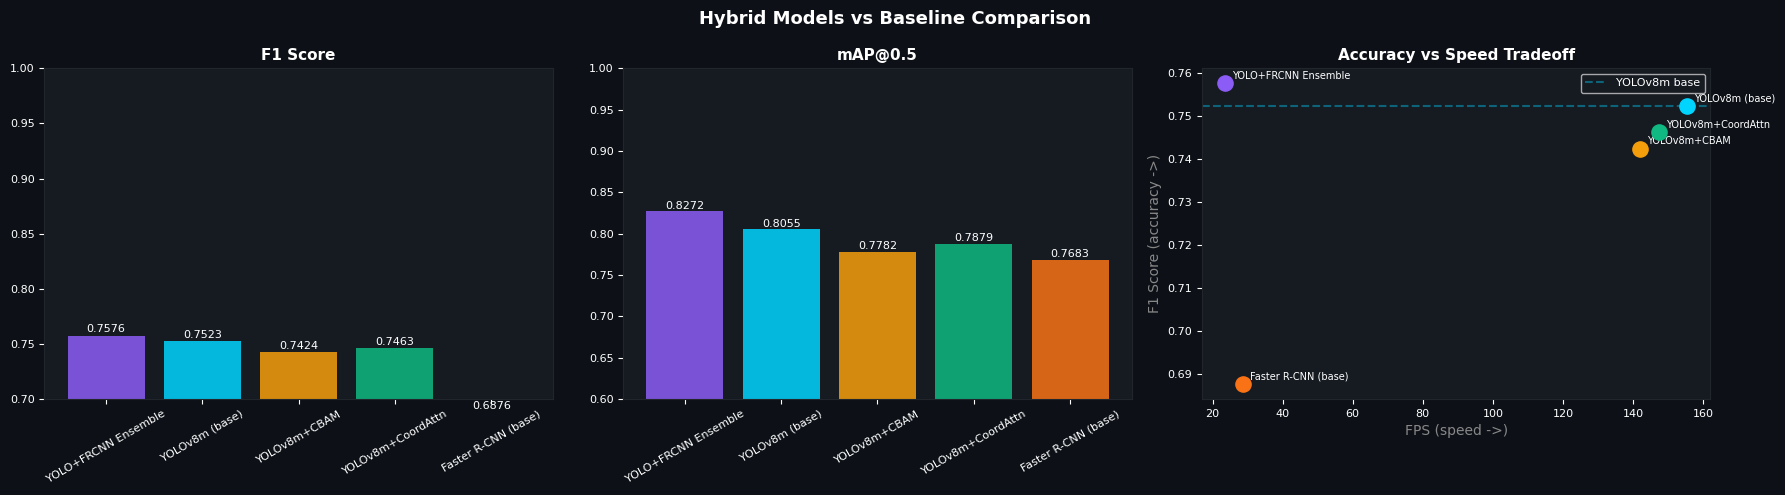

Saved -> ./hybrid_results/hybrid_comparison.png


In [27]:
# Renders the F1, mAP@0.5 and FPS comparison bar charts.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0d1117")

models = df["Model"].tolist()
colors = [PALETTE.get(m, "#94a3b8") for m in models]

for ax in axes:
    ax.set_facecolor("#161b22")
    for sp in ax.spines.values():
        sp.set_edgecolor("#21262d")
    ax.tick_params(colors="white", labelsize=8)
    ax.yaxis.label.set_color("#888")

# F1 Score
bars0 = axes[0].bar(models, df["F1"], color=colors, alpha=0.85)
axes[0].set_title("F1 Score", color="white", fontsize=11, fontweight="bold")
axes[0].set_ylim(0.7, 1.0)
axes[0].tick_params(axis="x", rotation=30)
for bar, val in zip(bars0, df["F1"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{val:.4f}",
        ha="center",
        color="white",
        fontsize=8,
    )

# mAP@0.5
bars1 = axes[1].bar(models, df["mAP@0.5"], color=colors, alpha=0.85)
axes[1].set_title("mAP@0.5", color="white", fontsize=11, fontweight="bold")
axes[1].set_ylim(0.6, 1.0)
axes[1].tick_params(axis="x", rotation=30)
for bar, val in zip(bars1, df["mAP@0.5"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{val:.4f}",
        ha="center",
        color="white",
        fontsize=8,
    )

# Accuracy-Speed Tradeoff
axes[2].set_facecolor("#161b22")
for m, row in df.iterrows():
    c = PALETTE.get(row["Model"], "#94a3b8")
    axes[2].scatter(row["FPS"], row["F1"], color=c, s=120, zorder=5)
    axes[2].annotate(
        row["Model"],
        (row["FPS"], row["F1"]),
        textcoords="offset points",
        xytext=(5, 3),
        color="white",
        fontsize=7,
    )
axes[2].set_xlabel("FPS (speed ->)", color="#888")
axes[2].set_ylabel("F1 Score (accuracy ->)", color="#888")
axes[2].set_title(
    "Accuracy vs Speed Tradeoff", color="white", fontsize=11, fontweight="bold"
)
axes[2].axhline(
    base_results["YOLOv8m (base)"]["F1"],
    color="#00d4ff",
    linestyle="--",
    alpha=0.4,
    label="YOLOv8m base",
)
axes[2].legend(facecolor="#161b22", labelcolor="white", fontsize=8)

plt.suptitle(
    "Hybrid Models vs Baseline Comparison",
    color="white",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
out = f"{OUTPUT_DIR}/hybrid_comparison.png"
plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Saved -> {out}")

In [28]:
# Prints where each hybrid's weights and attention state were saved and zips the notebook's outputs.
import zipfile

print("Hybrid model weights saved:")
print(f"  YOLOv8m+CBAM      at {dest_cbam}  (+ {cbam_attn_path})")
print(f"  YOLOv8m+CoordAttn at {dest_ca}  (+ {ca_attn_path})")
print(f"  YOLO+FRCNN Ensemble uses: {YOLOV8M_WEIGHTS} + {FASTERRCNN_WEIGHTS}")
print(
    "\n  NOTE: the attention hybrids need BOTH files -- the .pt alone is a "
    "plain YOLOv8m.\n  Re-attach the injector and load the attention state "
    "before inference (see Cell 7)."
)

# Zip all outputs
zip_path = os.path.join(ROOT, "hybrid_results.zip")
with zipfile.ZipFile(zip_path, "w") as zf:
    from pathlib import Path

    for f in Path(OUTPUT_DIR).glob("*"):
        zf.write(f, f.name)
print(f"\nAll outputs zipped to {zip_path}")

print("\nFinal Summary:")
print(
    df[["Model", "F1", "F1@best", "best_conf", "mAP@0.5", "FPS"]].to_string(index=False)
)


Hybrid model weights saved:
  YOLOv8m+CBAM      at ./hybrid_models/YOLOv8m_CBAM_v3.pt  (+ ./hybrid_models/YOLOv8m_CBAM_v3_attention_state.pt)
  YOLOv8m+CoordAttn at ./hybrid_models/YOLOv8m_CoordAttn_v3.pt  (+ ./hybrid_models/YOLOv8m_CoordAttn_v3_attention_state.pt)
  YOLO+FRCNN Ensemble uses: ./saved_models/YOLOv8m_finetuned.pt + ./saved_models/faster_rcnn_finetuned.pth

  NOTE: the attention hybrids need BOTH files -- the .pt alone is a plain YOLOv8m.
  Re-attach the injector and load the attention state before inference (see Cell 7).

All outputs zipped to ./hybrid_results.zip

Final Summary:
              Model     F1  F1@best  best_conf  mAP@0.5   FPS
YOLO+FRCNN Ensemble 0.7576   0.7774       0.20   0.8272  23.6
     YOLOv8m (base) 0.7523   0.7570       0.40   0.8055 155.5
       YOLOv8m+CBAM 0.7424   0.7541       0.35   0.7782 142.0
  YOLOv8m+CoordAttn 0.7463   0.7495       0.30   0.7879 147.3
Faster R-CNN (base) 0.6876   0.7281       0.70   0.7683  28.8


---
## Paper export

Bundles **this notebook's** figures, tables and raw metrics (everything under
its own `OUTPUT_DIR`) into one timestamped zip, with a
tidy `all_metrics.csv` to plot from, a booktabs `results_table.tex`, and a
`manifest.json` recording the environment, the split, and the exact metric
definitions behind the numbers. Also warns when a figure is older than the
newest metrics table -- i.e. was probably drawn from superseded numbers.


In [29]:
# Bundles this notebook's figures, tables and raw metrics into a timestamped zip with a tidy all_metrics.csv, a booktabs results_table.tex, and a manifest.json recording environment, split and metric definitions.

import os, re, json, zipfile, hashlib, platform, shutil, glob as _g
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd

BUNDLE_NAME = "pothole_hybrid"  # this notebook
EXPORT_STEM = f"{BUNDLE_NAME}_results"

# Extra directories to include, if this notebook writes results outside
# OUTPUT_DIR. Model weights (.pt/.pth) are never collected only figures,
# tables and raw metrics, by extension.
EXTRA_RESULT_DIRS = []

# Runs whose results must never reach a paper table. 'smoke_' are the
# 1-epoch pipeline smoke tests (mAP ~0.35) -- real-looking numbers from a
# deliberately untrained model. Excluded by name and reported, never
# dropped silently.
EXCLUDE_RUN_PREFIXES = ("smoke_",)

EXTERNAL_RESULT_VARS = {"BASELINES", "existing_results", "PREV_ATTENTION_RESULT"}
INCLUDE_EXTERNAL = False

FIG_EXT = {".png", ".pdf", ".svg", ".eps"}
TABLE_EXT = {".csv"}
RAW_EXT = {".json", ".txt", ".yaml", ".yml"}


# This notebook's result directories only
result_dirs, seen = [], set()
for d in [OUTPUT_DIR] + list(EXTRA_RESULT_DIRS):
    rp = os.path.realpath(d)
    if os.path.isdir(rp) and rp not in seen:
        seen.add(rp)
        result_dirs.append(rp)

print(f"Bundling results for: {BUNDLE_NAME}")
for d in result_dirs:
    n = sum(1 for _ in Path(d).rglob("*") if _.is_file())
    print(f"   {d}  ({n} files)")
if not result_dirs:
    print(
        f"   OUTPUT_DIR does not exist ({OUTPUT_DIR}) -- "
        f"run this notebook's evaluation cells first"
    )


#  Harvest metrics from memory and from every CSV on disk
METRIC_KEYS = {"mAP@0.5", "F1"}


VAR_NAME_MAP = {
    "cbam_result": "YOLOv8m+CBAM",
    "ca_result": "YOLOv8m+CoordAttn",
    "ensemble_result": "YOLO+FRCNN Ensemble",
    "yolo_base_result": "YOLOv8m (base)",
    "frcnn_base_result": "Faster R-CNN (base)",
    "rcnn_result": "Faster R-CNN",
    "ssd_result": "SSD-VGG16",
    "rtdetr_result": "RT-DETR",
}


def harvest_in_memory():
    rows, skipped = [], []
    for name, val in list(globals().items()):
        if name.startswith("_") or not isinstance(val, dict) or not val:
            continue
        if name in EXTERNAL_RESULT_VARS and not INCLUDE_EXTERNAL:
            continue
        if METRIC_KEYS <= set(val):  # a single result dict
            if name in VAR_NAME_MAP:
                rows.append(
                    {
                        "Model": VAR_NAME_MAP[name],
                        "origin": "this-notebook",
                        "source": "in-memory",
                        **{k: v for k, v in val.items() if not k.startswith("_")},
                    }
                )
            else:
                skipped.append(name)
        elif all(isinstance(v, dict) for v in val.values()):  # dict keyed by model
            for k, v in val.items():
                if METRIC_KEYS <= set(v):
                    rows.append(
                        {
                            "Model": k,
                            "origin": "external"
                            if name in EXTERNAL_RESULT_VARS
                            else "this-notebook",
                            "source": "in-memory",
                            **{
                                kk: vv for kk, vv in v.items() if not kk.startswith("_")
                            },
                        }
                    )
    if skipped:
        print(
            f"   note: unmapped in-memory result variable(s) {skipped} -- "
            f"add them to VAR_NAME_MAP to include them"
        )
    return rows


def harvest_result_jsons(dirs):
    """Harvest per-run JSON results written by the training loop."""
    rows = []
    for d in dirs:
        for jf in sorted(Path(d).rglob("*.json")):
            try:
                blob = json.load(open(jf))
            except Exception:
                continue
            for rec in blob if isinstance(blob, list) else [blob]:
                if not isinstance(rec, dict):
                    continue
                md = rec.get("metrics_default")
                mb = rec.get("metrics_best") or {}
                if isinstance(md, dict) and METRIC_KEYS <= set(md):
                    name = (
                        rec.get("run_name")
                        or rec.get("model")
                        or jf.stem.replace("_result", "")
                    )
                    row = {
                        "Model": name,
                        "origin": "this-notebook",
                        "source": os.path.relpath(jf),
                    }
                    row.update({k: v for k, v in md.items() if k != "conf"})
                    if isinstance(mb, dict) and mb:
                        row["best_conf"] = rec.get("best_conf", mb.get("conf"))
                        for src_k, dst_k in [
                            ("Precision", "P@best"),
                            ("Recall", "R@best"),
                            ("F1", "F1@best"),
                        ]:
                            if src_k in mb:
                                row[dst_k] = mb[src_k]
                    for extra in ("seed", "attention"):
                        if extra in rec:
                            row[extra] = rec[extra]
                    rows.append(row)
                elif METRIC_KEYS <= set(rec):
                    rows.append(
                        {
                            "Model": rec.get("run_name") or jf.stem,
                            "origin": "this-notebook",
                            "source": os.path.relpath(jf),
                            **{
                                k: v
                                for k, v in rec.items()
                                if not isinstance(v, (dict, list))
                            },
                        }
                    )
    return rows


def harvest_csvs(dirs):
    rows = []
    for d in dirs:
        for csv in Path(d).rglob("*.csv"):
            try:
                sub = pd.read_csv(csv)
            except Exception:
                continue
            if "Model" not in sub.columns or not (METRIC_KEYS & set(sub.columns)):
                continue
            for _, r in sub.iterrows():
                rows.append(
                    {
                        "origin": "this-notebook",
                        "source": os.path.relpath(csv),
                        **r.to_dict(),
                    }
                )
    return rows


rows = (
    harvest_result_jsons(result_dirs) + harvest_in_memory() + harvest_csvs(result_dirs)
)

_excluded = [
    r["Model"] for r in rows if str(r.get("Model", "")).startswith(EXCLUDE_RUN_PREFIXES)
]
rows = [r for r in rows if not str(r.get("Model", "")).startswith(EXCLUDE_RUN_PREFIXES)]
if _excluded:
    print(
        f"   excluded {len(_excluded)} non-final run(s) from the metrics table: "
        f"{sorted(set(_excluded))}"
    )

# Scope guard: keep only what THIS notebook measured.
if not INCLUDE_EXTERNAL:
    _ext = sorted({r["Model"] for r in rows if r.get("origin") != "this-notebook"})
    rows = [r for r in rows if r.get("origin") == "this-notebook"]
    if _ext:
        print(
            f"   excluded {len(_ext)} external/baseline row(s) -- this bundle is "
            f"scoped to {BUNDLE_NAME} only: {_ext}"
        )
if rows:
    metrics_df = pd.DataFrame(rows)
    # in-memory wins over a possibly-stale CSV for the same model
    metrics_df["_rank"] = (metrics_df["source"] != "in-memory").astype(int)
    metrics_df = (
        metrics_df.sort_values("_rank")
        .drop_duplicates(subset=["Model"], keep="first")
        .drop(columns="_rank")
    )
    front = [
        c
        for c in [
            "Model",
            "mAP@0.5",
            "mAP@0.5:0.95",
            "Precision",
            "Recall",
            "F1",
            "best_conf",
            "P@best",
            "R@best",
            "F1@best",
            "FPS",
            "TP",
            "FP",
            "FN",
            "attention",
            "seed",
            "source",
        ]
        if c in metrics_df.columns
    ]
    metrics_df = metrics_df[
        front + [c for c in metrics_df.columns if c not in front and c != "origin"]
    ]
    # sort on F1@best, falling back to F1 per-row so models evaluated without
    # a confidence sweep are ranked on their own F1 instead of sorting as NaN
    _key = metrics_df["F1"] if "F1" in metrics_df.columns else 0.0
    if "F1@best" in metrics_df.columns:
        _key = metrics_df["F1@best"].fillna(_key)
    metrics_df = (
        metrics_df.assign(_key=_key)
        .sort_values("_key", ascending=False)
        .drop(columns="_key")
        .reset_index(drop=True)
    )
    print(f"\nCollected {len(metrics_df)} model rows -- all from {BUNDLE_NAME}")
    if len(metrics_df) == 0:
        print(
            "   WARNING: none of this notebook's own runs were collected -- "
            "check that its result JSON/CSV files are in OUTPUT_DIR"
        )
else:
    metrics_df = pd.DataFrame()
    print("\nNo metric rows found -- run the evaluation cells first")


# Stage the bundle
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
stage = os.path.join(ROOT, f"{EXPORT_STEM}_{stamp}")
zip_path = stage + ".zip"
for sub in ("figures", "metrics", "raw"):
    os.makedirs(os.path.join(stage, sub), exist_ok=True)

inventory, name_counts = [], {}


def stage_file(src, sub):
    """Copy into the bundle, prefixing on collision so nothing is silently lost."""
    base = os.path.basename(src)
    parent = os.path.basename(os.path.dirname(src))
    key = (sub, base)
    name_counts[key] = name_counts.get(key, 0) + 1
    dst_name = base if name_counts[key] == 1 else f"{parent}__{base}"
    dst = os.path.join(stage, sub, dst_name)
    if os.path.exists(dst):
        dst = os.path.join(stage, sub, f"{parent}__{base}")
    shutil.copy2(src, dst)
    h = hashlib.sha256(open(src, "rb").read()).hexdigest()[:16]
    inventory.append(
        {
            "bundle_path": os.path.relpath(dst, stage),
            "source": os.path.relpath(src),
            "bytes": os.path.getsize(src),
            "modified": datetime.fromtimestamp(os.path.getmtime(src)).isoformat(
                timespec="seconds"
            ),
            "sha256_16": h,
        }
    )


for d in result_dirs:
    for f in sorted(Path(d).rglob("*")):
        if not f.is_file():
            continue
        ext = f.suffix.lower()
        sub = (
            "figures"
            if ext in FIG_EXT
            else "metrics"
            if ext in TABLE_EXT
            else "raw"
            if ext in RAW_EXT
            else None
        )
        if sub:
            stage_file(str(f), sub)

# consolidated tables
if not metrics_df.empty:
    metrics_df.to_csv(os.path.join(stage, "metrics", "all_metrics.csv"), index=False)
    metrics_df.to_json(
        os.path.join(stage, "metrics", "all_metrics.json"), orient="records", indent=2
    )
    tex_cols = [
        c
        for c in ["Model", "mAP@0.5", "Precision", "Recall", "F1", "FPS"]
        if c in metrics_df.columns
    ]
    try:
        # Format to strings first: pandas' float_format would print FPS
        def _tex_escape(v):
            return (
                str(v)
                .replace("\\", r"\textbackslash{}")
                .replace("_", r"\_")
                .replace("&", r"\&")
                .replace("%", r"\%")
                .replace("#", r"\#")
            )

        tex_df = metrics_df[tex_cols].copy()
        for c in tex_cols:
            if c == "Model":
                tex_df[c] = tex_df[c].map(_tex_escape)
            else:
                dp = 1 if c == "FPS" else 4
                tex_df[c] = tex_df[c].map(
                    lambda v, dp=dp: "--" if pd.isna(v) else f"{float(v):.{dp}f}"
                )
        tex = tex_df.to_latex(
            index=False,
            escape=False,
            column_format="l" + "r" * (len(tex_cols) - 1),
            caption=(
                "Pothole detection results on the held-out validation split. "
                "mAP@0.5 is COCO 101-point interpolated; FPS is throughput "
                "(images/total time) with warm-up discarded. "
                "-- indicates the metric was not measured for that model."
            ),
            label="tab:pothole_results",
        )
        open(os.path.join(stage, "metrics", "results_table.tex"), "w").write(tex)
    except Exception as e:
        print(f"   (LaTeX table skipped: {e})")


# Provenance manifest
def _ver(mod):
    try:
        return __import__(mod).__version__
    except Exception:
        return None


def _n_gt(recs):
    try:
        return int(sum(len(r["gt_boxes"]) for r in recs))
    except Exception:
        return None


manifest = {
    "notebook": BUNDLE_NAME,
    "created": datetime.now().isoformat(timespec="seconds"),
    "notebook_root": os.path.realpath(ROOT),
    "result_dirs": result_dirs,
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "numpy": _ver("numpy"),
        "pandas": _ver("pandas"),
        "torch": _ver("torch"),
        "ultralytics": _ver("ultralytics"),
        "opencv": _ver("cv2"),
        "torchvision": _ver("torchvision"),
        "device": globals().get("DEVICE"),
        "gpu": (
            torch.cuda.get_device_name(0) if globals().get("DEVICE") == "cuda" else None
        ),
    },
    "dataset": {
        "sources": [
            "chitholian/annotated-potholes-dataset",
            "andrewmvd/pothole-detection",
            "ashishkumarak/training-setzip",
        ],
        "dedup": "normalized 64x64 grayscale nearest-neighbour, mean-abs threshold 1.0",
        "n_images_after_dedup": len(globals().get("records", []) or []) or None,
        "n_train": len(globals().get("train_recs", []) or []) or None,
        "n_val": len(globals().get("val_recs", []) or []) or None,
        "n_val_gt_boxes": _n_gt(globals().get("val_recs", []) or []),
        "split_seed": 42,
        "split": "80/20 shuffled after dedup",
    },
    "metric_definitions": {
        "mAP@0.5": "COCO 101-point interpolated AP at IoU 0.5 "
        "(matches ultralytics.utils.metrics.compute_ap)",
        "mAP@0.5(VOC11)": "legacy PASCAL VOC-2007 11-point AP -- reported for "
        "continuity only, NOT comparable with model.val()",
        "matching": "greedy by descending confidence; each detection matched to "
        "the highest-IoU ground truth that is still unmatched",
        "iou_threshold": 0.5,
        "conf_fixed": globals().get("CONF_THRESH", globals().get("CONF_DEFAULT")),
        "conf_sweep": globals().get("CONF_SWEEP"),
        "F1": "at the fixed confidence threshold",
        "F1@best": "at the confidence maximising F1 (sweep) -- use this when "
        "comparing against Ultralytics model.val() numbers",
        "FPS": "throughput = images / total wall-clock, first 5 iterations "
        "discarded as warm-up, CUDA-synchronised",
    },
    "files": inventory,
}
json.dump(manifest, open(os.path.join(stage, "manifest.json"), "w"), indent=2)


#  Staleness check
# Any figure older than the newest metrics table was almost certainly drawn
# from superseded numbers.
warnings_out = []
csv_times = [
    f["modified"] for f in inventory if f["bundle_path"].startswith("metrics/")
]
if csv_times:
    newest = max(csv_times)
    stale = [
        f
        for f in inventory
        if f["bundle_path"].startswith("figures/") and f["modified"] < newest
    ]
    if stale:
        warnings_out.append(
            f"{len(stale)} figure(s) predate the newest metrics table ({newest}) -- "
            "they may have been rendered from superseded numbers:"
        )
        for f in stale[:10]:
            warnings_out.append(f"    {f['bundle_path']}  ({f['modified']})")
        if len(stale) > 10:
            warnings_out.append(f"    ... and {len(stale) - 10} more")


#  README + zip
readme = f"""POTHOLE DETECTION -- PAPER BUNDLE
Notebook: {BUNDLE_NAME}
Created:  {manifest["created"]}

Scope: results from THIS notebook only ({OUTPUT_DIR}). Each notebook in the
project has its own export cell and produces its own bundle.

  metrics/all_metrics.csv    every model x every metric, tidy -- plot from this
  metrics/all_metrics.json   same, JSON
  metrics/results_table.tex  booktabs LaTeX, \\input{{}} directly
  metrics/*.csv              per-notebook result tables as generated
  figures/                   all .png/.pdf figures produced by the notebooks
  raw/                       per-run JSON, configs, logs
  manifest.json              versions, split, seed, exact metric definitions
                             + sha256 of every file

METRICS -- read before quoting any number
  mAP@0.5 is COCO 101-point interpolated (same as Ultralytics model.val()).
  Any 'mAP@0.5(VOC11)' column is the legacy VOC-2007 11-point figure and must
  NOT be tabled next to a COCO number.
  F1 is at a fixed confidence threshold; F1@best is at the F1-maximising
  threshold. Ultralytics' model.val() reports the latter, so use F1@best for
  cross-comparison and say which one the paper quotes.
  FPS is throughput (images / total time), warm-up discarded, CUDA-synced.

All numbers are on the held-out validation split
({manifest["dataset"]["n_val"]} images, {manifest["dataset"]["n_val_gt_boxes"]} GT boxes, seed 42).
"""
open(os.path.join(stage, "README.txt"), "w").write(readme)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(Path(stage).rglob("*")):
        if f.is_file():
            zf.write(f, f.relative_to(os.path.dirname(stage)))

n_fig = sum(1 for f in inventory if f["bundle_path"].startswith("figures/"))
n_tab = sum(1 for f in inventory if f["bundle_path"].startswith("metrics/"))
n_raw = sum(1 for f in inventory if f["bundle_path"].startswith("raw/"))

print("\n" + "=" * 62)
print(f"  BUNDLE -> {zip_path}")
print(
    f"  {os.path.getsize(zip_path) / 1e6:.2f} MB   "
    f"{n_fig} figures, {n_tab} tables, {n_raw} raw, {len(metrics_df)} model rows"
)
print(f"  staged (unzipped) at {stage}")
print("=" * 62)
if not metrics_df.empty:
    show = [
        c
        for c in ["Model", "mAP@0.5", "F1", "F1@best", "FPS"]
        if c in metrics_df.columns
    ]
    print(metrics_df[show].to_string(index=False))
if warnings_out:
    print("\nWARNINGS")
    for w in warnings_out:
        print("  " + w)
else:
    print("\nNo staleness warnings.")


Bundling results for: pothole_hybrid
   /home/vr3/Pothole_Detection/Updated Code 926/Hybrid Models Final/hybrid_results  (3 files)

Collected 5 model rows -- all from pothole_hybrid

  BUNDLE -> ./pothole_hybrid_results_20260827_172057.zip
  0.11 MB   1 figures, 1 tables, 1 raw, 5 model rows
  staged (unzipped) at ./pothole_hybrid_results_20260827_172057
              Model  mAP@0.5     F1  F1@best   FPS
YOLO+FRCNN Ensemble   0.8272 0.7576   0.7774  23.6
     YOLOv8m (base)   0.8055 0.7523   0.7570 155.5
       YOLOv8m+CBAM   0.7782 0.7424   0.7541 142.0
  YOLOv8m+CoordAttn   0.7879 0.7463   0.7495 147.3
Faster R-CNN (base)   0.7683 0.6876   0.7281  28.8

No staleness warnings.
